# NB_T2a · RAG & GraphRAG : Vins du Jura

🏗️ Build | 🚢 Ship | 📤 Share · ⏱️ ~120 min · LangChain seul (aucun LangGraph)

### 🏗️ Build
Indexer un corpus avec `mistral-embed` · retrieval **hybride** dense + BM25 fusionné par
RRF · extraire un graphe de connaissances avec `with_structured_output` et l'interroger.

### 🚢 Ship
Trois pipelines sur le même corpus (**vectoriel** → **hybride** → **GraphRAG**),
confrontés aux mêmes questions et notés par un juge LLM.

### 📤 Share
Le coût réel de chaque approche, et de quoi choisir en connaissance de cause.

**Pré-requis.** `vins_jura.py` et `corpus_vins/` (même dossier), un `.env` à la racine avec
`MISTRAL_API_KEY` et `MISTRAL_SERVER_URL`, puis `uv sync`. Pièges serveur, grille de
décision et références académiques : [`README.md`](README.md).

### 🧭 Notre signalétique

| Marqueur | Sens |
|---|---|
| 💡 **L'idée en deux mots** | l'intuition de la section, avant la technique |
| `## Chapitre N ·` | une grande étape du pipeline |
| `## Task N.M ·` | une brique à construire |
| 🔮 **Pause prédiction** | arrêtez-vous et pronostiquez avant d'exécuter |
| 👀 **Résultat attendu** | ce que vous devez voir sortir |
| ⚠️ **Piège** | l'erreur que tout le monde fait une fois |
| 🎯 **À retenir** | ce qui reste quand on a oublié le code |
| 🙊 **Note honnête** | les limites de la démonstration, dites franchement |
| 📚 **Documentation** | la page officielle à garder ouverte |

> 🙊 **Note honnête.** Le corpus, ce sont les **sept cahiers des charges des AOC du Jura**,
> homologués par décret et publiés par l'INAO. Rien n'est inventé : chaque réponse du système
> est vérifiable à la ligne près dans un texte réglementaire.
>
> Cela change la nature de l'exercice. Ces documents ne parlent ni de domaines ni de
> vignerons, mais d'**appellations** : types de produit, mentions, cépages autorisés, aires,
> rendements, durées d'élevage. Et ils sont volumineux — 230 000 caractères au total, contre
> quelques milliers pour une fiche produit.

## Pourquoi le RAG ?

> 💡 **L'idée en deux mots.** Un LLM, c'est un candidat qui a révisé une encyclopédie
> l'an dernier et qui passe l'examen de mémoire, sans rien sur la table. Le RAG, c'est
> l'autoriser à ouvrir **vos** classeurs pendant l'épreuve. On ne lui a rien réappris :
> on a posé les bons documents devant lui, au moment de la question.
>
> *(indexation = ranger les classeurs · retrieval = sortir la bonne chemise ·
> génération = rédiger la réponse en la lisant)*

**Retrieval-Augmented Generation** (Lewis et al. 2020, arXiv:2005.11401). Un LLM ne
connaît que ce qu'il a vu à l'entraînement. Vos contrats, vos délibérations n'y sont pas,
et le réentraîner à chaque mise à jour est hors de prix. Le RAG ne touche pas au modèle :
il lui **met les bons documents sous les yeux** au moment de la question.

| Étape | Ce qu'on fait | Quand |
|---|---|---|
| **Indexation** | découper, vectoriser, stocker | une fois, hors ligne |
| **Retrieval** | retrouver les passages proches de la question | à chaque question |
| **Génération** | répondre *à partir de ces passages* | à chaque question |

**Et sa limite est structurelle.** Le vectoriel retrouve ce qui *ressemble* à la question.
Si la réponse exige de relier deux faits situés dans deux documents différents, aucune
recherche par similarité ne la trouvera : le passage qui contient la réponse n'existe pas.

> 🎯 **À retenir.** Le RAG n'apprend rien au modèle, il change ce qu'il a sous les yeux.
> Toute la difficulté est donc dans le *retrieval*, pas dans la génération.

## Glossaire

| Terme | Définition courte |
|---|---|
| **chunk** | Morceau de document indexé séparément : l'unité que le retrieval renvoie |
| **embedding** | Vecteur représentant le sens d'un texte (`mistral-embed` : 1 024 dimensions) |
| **similarité cosinus** | Mesure d'angle entre deux vecteurs, dans `[-1, 1]` : 1 = même direction |
| **top-k** | Les `k` chunks les plus proches, seuls transmis au LLM |
| **dense** | Recherche par embeddings : trouve le sens, même sans mot commun |
| **sparse (lexical)** | Recherche par mots exacts (BM25) : trouve termes rares et noms propres |
| **hybride** | Combinaison des deux, fusionnée par RRF |
| **RRF** | Reciprocal Rank Fusion : fusionne des classements par leurs **rangs**, pas leurs scores |
| **retriever** | Abstraction LangChain : `question → liste de documents` |
| **LCEL** | LangChain Expression Language, pour composer avec `\|` : `prompt`, `llm`, `parser` |
| **triplet** | Fait élémentaire d'un graphe : `sujet -[RELATION]-> objet` |
| **entity linking** | Retrouver dans le graphe les nœuds dont parle la question |
| **traversée k-hop** | Suivre `k` relations depuis un nœud d'ancrage |
| **multi-hop** | Question dont la réponse exige d'enchaîner plusieurs relations |

## 🗺️ La carte du notebook

```text
         corpus_vins/  (7 cahiers des charges INAO, HTML)
                               │
        ┌──────────────────────┴──────────────────────┐
   Ch. 1-2 : on indexe les MOTS            Ch. 5 : on indexe les RELATIONS
        │                                             │
   chunks → mistral-embed → index          fiches → with_structured_output
        │      + BM25                              │      (triplets typés)
        ▼                                          ▼
   dense ─┐                                   graphe NetworkX
   BM25 ──┼─► RRF ─► top-k                         │
          ▼                            entity linking ─► traversée k-hop
   Ch. 3 : chaîne LCEL                              │
   prompt | llm | parser                            ▼
        │                                 sous-graphe sérialisé
        ▼                                           │
   ❌ 3 questions échouent ── Ch. 4 ──►  ✅ les 3 mêmes réussissent
      (le « mur »)      Multi-Query, HyDE
                        ne suffisent pas             │
                                                     ▼
                                    Ch. 6 : mesurer, chiffrer, décider
```

In [1]:
# ── Environnement : modèle de chat, modèle d'embedding, corpus ───────────────
import os, re, textwrap

from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())

if not os.getenv('MISTRAL_API_KEY'):
    raise ValueError('❌ MISTRAL_API_KEY absente. Créez un .env à la racine du dépôt.')
if not os.getenv('MISTRAL_SERVER_URL'):
    raise ValueError('❌ MISTRAL_SERVER_URL absente. Créez un .env à la racine du dépôt.')

from langchain_mistralai import ChatMistralAI, MistralAIEmbeddings

# Gotcha serveur dédié : langchain-mistralai poste sur {endpoint}/chat/completions
# et {endpoint}/embeddings → il faut ajouter /v1 soi-même. Vrai pour les DEUX clients.
_base = os.environ['MISTRAL_SERVER_URL'].rstrip('/')
_EP = _base if _base.endswith('/v1') else _base + '/v1'

MODELE_CHAT  = 'mistral-medium-latest'
MODELE_EMBED = 'mistral-embed'

llm = ChatMistralAI(model=MODELE_CHAT, temperature=0, endpoint=_EP)
emb = MistralAIEmbeddings(model=MODELE_EMBED, endpoint=_EP)

from vins_jura import (
    CORPUS_DIR, RELATIONS, TRIPLETS_REFERENCE,
    QUESTIONS_SIMPLES, QUESTIONS_MULTIHOP, QUESTIONS_HORS_SCOPE,
    charger_corpus, cosinus, rrf,
)

_dim = len(emb.embed_query('test'))

print('┌─────────────────────────────────────────────────────────┐')
print('│  🍇  NB_T2a · RAG & GraphRAG · Vins du Jura              │')
print('├─────────────────────────────────────────────────────────┤')
print(f'│  🤖  Chat       : {MODELE_CHAT}  •  temperature=0')
print(f'│  🧬  Embedding  : {MODELE_EMBED}  •  {_dim} dimensions')
print(f'│  📚  Corpus     : {len(charger_corpus())} cahiers des charges dans {CORPUS_DIR.name}/')
print(f'│  🕸️   Graphe gold: {len(TRIPLETS_REFERENCE)} triplets  •  {len(RELATIONS)} relations')
print(f'│  ❓  Questions  : {len(QUESTIONS_SIMPLES)} simples · '
      f'{len(QUESTIONS_MULTIHOP)} multi-sauts · {len(QUESTIONS_HORS_SCOPE)} hors-scope')
print('└─────────────────────────────────────────────────────────┘')

┌─────────────────────────────────────────────────────────┐
│  🍇  NB_T2a · RAG & GraphRAG · Vins du Jura              │
├─────────────────────────────────────────────────────────┤
│  🤖  Chat       : mistral-medium-latest  •  temperature=0
│  🧬  Embedding  : mistral-embed  •  1024 dimensions
│  📚  Corpus     : 7 cahiers des charges dans corpus_vins/
│  🕸️   Graphe gold: 75 triplets  •  6 relations
│  ❓  Questions  : 4 simples · 3 multi-sauts · 3 hors-scope
└─────────────────────────────────────────────────────────┘


> 👀 **Résultat attendu :** 1 024 dimensions, 7 cahiers des charges, 74 triplets de référence. Ni la clé ni l'URL du
> serveur ne sont affichées : dans un dépôt public, les sorties de notebook sont du contenu
> versionné comme le reste.

---

## Chapitre 1 · Indexer : du corpus à l'index interrogeable

> 💡 **L'idée en deux mots.** Sept appellations, sept textes réglementaires. Chacun est
> exhaustif sur son appellation et **totalement muet sur les six autres** : aucun cahier
> des charges ne dit « au fait, l'appellation voisine autorise les mêmes cépages ».
> Gardez cette phrase en tête, c'est tout le problème du notebook.

Chaque document décrit **une appellation**, de façon complète et autonome : nom, couleurs,
aire géographique, encépagement, rendements, élevage, étiquetage. Et aucun ne se compare à
un autre. Cette fragmentation n'a rien de construit pour l'exercice : c'est la situation
normale d'un fonds documentaire réel. Un dossier, une délibération, un contrat ne parlent
que de leur objet, et les liens entre eux ne sont écrits nulle part.

D'où viendra la difficulté, alors ? De la **comparaison**. « Quelle appellation impose le
rendement le plus bas », « quel cépage est commun aux sept » : ces questions n'ont de
réponse dans aucun des sept textes, seulement dans leur mise en regard.

In [2]:
# ── Chargement du corpus ─────────────────────────────────────────────────────
fiches = charger_corpus()

print('─' * 74)
print(f'📚  Corpus : {len(fiches)} fiches')
print('─' * 74)
for f in fiches:
    print(f'  {f["fichier"]:30s} {len(f["texte"]):5d} car.   {f["titre"]}')
print('─' * 74)
print(f'  Total : {sum(len(f["texte"]) for f in fiches)} caractères')

──────────────────────────────────────────────────────────────────────────
📚  Corpus : 7 fiches
──────────────────────────────────────────────────────────────────────────
  arbois.html                    41707 car.   Cahier des charges — AOC Arbois
  chateau-chalon.html            28111 car.   Cahier des charges — AOC Château-Chalon
  cotes-du-jura.html             39955 car.   Cahier des charges — AOC Côtes du Jura
  cremant-du-jura.html           37063 car.   Cahier des charges — AOC Crémant du Jura
  letoile.html                   35915 car.   Cahier des charges — AOC L'Étoile
  macvin-du-jura.html            27147 car.   Cahier des charges — AOC Macvin du Jura
  marc-du-jura.html              20027 car.   Cahier des charges — AOC Marc du Jura
──────────────────────────────────────────────────────────────────────────
  Total : 229925 caractères


---

## 🧬 Anatomie d'un cahier des charges

Ces sept documents ne sont pas de la prose libre : ils suivent tous **le même plan
réglementaire, en articles numérotés**. C'est une aubaine, parce que chaque article
alimente une relation de notre graphe et une seule.

```text
  ┌─────────────────────────────────────────────┐
  │  CAHIER DES CHARGES DE L'AOC « ... »        │
  ├─────────────────────────────────────────────┤        relation extraite
  │  I.    Nom de l'appellation                 │  ──►   (le sujet de tous les triplets)
  │  II.   Dénominations et mentions            │  ──►   ADMET_MENTION
  │  III.  Couleur et types de produit          │  ──►   PRODUIT_TYPE
  │  IV.   Aires et zones                       │  ──►   RECOLTEE_SUR   ⚠️ voir ci-dessous
  │  V.    Encépagement                         │  ──►   AUTORISE
  │  VI.   Conduite du vignoble                 │        (densité : l'exercice final)
  │  VII.  Récolte, transport, maturité         │
  │  VIII. Rendements                           │  ──►   RENDEMENT_MAX
  │  IX.   Transformation, élaboration, élevage │  ──►   ELEVAGE_MIN
  │  X.    Lien avec le milieu géographique     │
  │  XI.   Mesures transitoires                 │
  │  XII.  Étiquetage                           │
  └─────────────────────────────────────────────┘
```

### 🎯 Ce que cette structure change pour nous

- ✅ **L'extraction devient prévisible.** On peut dire au modèle *où* chercher chaque
  relation, et pas seulement *quoi* chercher. La consigne du chapitre 5 le fera.
- ⚠️ **L'article IV est un piège.** Il contient **deux** listes de communes : celles où
  la **récolte** a lieu (IV 1° a), et celles où la vinification et l'élevage **peuvent
  aussi** être assurés (IV 1° b). La seconde compte des dizaines de communes. Les
  confondre noie le graphe.
- 🙈 **Certains articles ne donnent rien.** VII, X, XI, XII sont riches en texte et pauvres
  en faits typables. Un graphe **jette** toujours une partie du document : c'est le prix à
  payer, et le chapitre 6 le chiffrera.

> 🎯 **À retenir.** Un corpus réglementaire est le terrain rêvé du GraphRAG : structure
> stable, vocabulaire contrôlé, faits atomiques. Un corpus de mails ou de comptes rendus
> de réunion, c'est exactement l'inverse — et c'est là que les projets échouent.


---

## Task 1.1 · Découper : le chunking

> 💡 **L'idée en deux mots.** Résumer un livre entier en une phrase, ça donne une phrase
> floue. Résumer chaque page, ça donne des phrases utiles. Découper, c'est choisir la
> taille de la page. Et comme une phrase peut tomber pile sur la coupure, chaque morceau
> reprend la fin du précédent.
>
> *(chunk = la page · `chunk_size` = sa taille · `chunk_overlap` = ce qu'on répète d'un
> morceau au suivant)*

**Pourquoi découper ?** D'abord pour une raison dure : `mistral-embed` plafonne autour de
8 192 tokens, et **quatre de nos sept cahiers des charges dépassent cette limite** (Arbois
fait ~10 700 tokens). Sans découpage, ils seraient tronqués silencieusement. Pour la **précision du retrieval** : un embedding est un
vecteur unique qui résume *tout* le texte reçu, donc vectoriser une fiche entière produit
une moyenne floue où les millésimes diluent les cépages. Découper donne à chaque passage
son propre vecteur, donc la possibilité d'être retrouvé pour lui-même.

`chunk_overlap` fait se chevaucher les morceaux voisins pour qu'une phrase coupée reste
lisible dans au moins un chunk. La convention du support GraphRAG est **512 tokens / 64 de
recouvrement**, soit 12,5 %. `RecursiveCharacterTextSplitter` comptant en **caractères**,
et le français faisant ~3,9 car./token, cela donne **2 000 caractères / 250**.

Sur un cahier des charges de 30 000 caractères, 2 000 produit une vingtaine de morceaux :
la convention s'applique enfin telle quelle. Un corpus de fiches produit courtes aurait
obligé à descendre bien plus bas pour que le découpage existe — c'est le genre d'arbitrage
que la taille réelle des documents décide, jamais une règle générale.

> ⚠️ **Piège.** `chunk_size` est un paramètre d'**indexation** : le changer impose de
> revectoriser tout le corpus. Il est dans la même famille que le choix du modèle
> d'embedding, du parseur et du schéma de métadonnées — par opposition à `k`, au prompt ou
> au reranker, qui se règlent à chaud sans rien réindexer.

> 📚 [Text splitters](https://docs.langchain.com/oss/python/langchain/split-text)

In [3]:
# ── Comparaison de trois tailles de découpage ────────────────────────────────
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

print('─' * 74)
print('✂️   Effet de chunk_size (recouvrement maintenu à 12,5 %)')
print('─' * 74)
print(f'  {"chunk_size":>12s}  {"overlap":>8s}  {"chunks":>7s}  {"car./chunk":>11s}')
# On fait varier la taille pour VOIR l'effet. Sur des textes réglementaires structurés
# en articles numérotés, un chunk trop petit coupe un article en plein milieu.
for taille in (700, 1000, 1500, 2000):
    s = RecursiveCharacterTextSplitter(chunk_size=taille, chunk_overlap=taille // 8)
    morceaux = [m for f in fiches for m in s.split_text(f['texte'])]
    moy = sum(len(m) for m in morceaux) / len(morceaux)
    marque = '  ← retenu' if taille == 2000 else ''
    print(f'  {taille:12d}  {taille // 8:8d}  {len(morceaux):7d}  {moy:11.0f}{marque}')

# ── Découpage retenu, en Document LangChain ──────────────────────────────────
# « Recursive » décrit sa stratégie de coupe. Les séparateurs PAR DÉFAUT sont
# ['\n\n', '\n', ' ', ''] : double saut de ligne, saut simple, espace, puis en plein
# mot. Il n'y a AUCUN séparateur de phrase — pour couper aux phrases il faut le
# demander : separators=['\n\n', '\n', '. ', ' ', ''].
SPLITTER = RecursiveCharacterTextSplitter(chunk_size=2000, chunk_overlap=250)

chunks = []
for f in fiches:
    for i, morceau in enumerate(SPLITTER.split_text(f['texte'])):
        chunks.append(Document(
            page_content=morceau,
            metadata={'source': f['fichier'], 'titre': f['titre'], 'chunk': i},
        ))


# ── Trois raccourcis d'affichage, réutilisés dans tout le notebook ───────────
def cle(d: Document) -> str:
    """Identifiant complet d'un chunk : « chateau-chalon.html#1 »."""
    return f'{d.metadata["source"]}#{d.metadata["chunk"]}'


# Un préfixe de 2 caractères ne suffit pas : « macvin-du-jura.html » et
# « marc-du-jura.html » donneraient tous deux « ma ». On mappe explicitement.
COURT = {
    'arbois.html': 'arbois',          'chateau-chalon.html': 'ch-chalon',
    'cotes-du-jura.html': 'cotes',    'cremant-du-jura.html': 'cremant',
    'letoile.html': 'letoile',        'macvin-du-jura.html': 'macvin',
    'marc-du-jura.html': 'marc',
}


def court(source: str) -> str:
    """Nom court d'un document, pour les tableaux : « ch-chalon »."""
    return COURT.get(source, source.removesuffix('.html'))


def etiquette(d: Document) -> str:
    """Forme courte, pour les tableaux côte à côte : « ch-chalon#1 »."""
    return f'{court(d.metadata["source"])}#{d.metadata["chunk"]}'


def fiches_vues(docs: list[Document]) -> list[str]:
    """Les appellations distinctes représentées dans un lot de chunks."""
    return sorted({court(d.metadata['source']) for d in docs})

print('─' * 74)
print(f'  {len(fiches)} fiches  →  {len(chunks)} chunks')
print(f'  Exemple : {chunks[0].metadata["source"]} #{chunks[0].metadata["chunk"]} :')
print(textwrap.indent(textwrap.fill(chunks[0].page_content[:260] + '...', 66), '    │ '))
print('─' * 74)

──────────────────────────────────────────────────────────────────────────
✂️   Effet de chunk_size (recouvrement maintenu à 12,5 %)
──────────────────────────────────────────────────────────────────────────
    chunk_size   overlap   chunks   car./chunk
           700        87      423          569
          1000       125      283          856
          1500       187      187         1311
          2000       250      139         1781  ← retenu
──────────────────────────────────────────────────────────────────────────
  7 fiches  →  139 chunks
  Exemple : arbois.html #0 :
    │ Cahier des charges — AOC Arbois Publié au BO du MASA le 15
    │ septembre 2022 Cahier des charges de l’appellation d’origine
    │ protégée « Arbois » homologué par l’arrêté du 2 septembre 2022
    │ publié au JORF du 9 septembre 2022 CAHIER DES CHARGES DE
    │ L’APPELLATION D’ORIG...
──────────────────────────────────────────────────────────────────────────


---

## Task 1.2 · Vectoriser : `mistral-embed` et la similarité cosinus

> 💡 **L'idée en deux mots.** Imaginez une carte géante où chaque texte est une ville,
> placée selon son **sens** et non son ordre alphabétique. « cépage » et « variété de
> raisin » atterrissent dans le même quartier sans partager un seul mot. Chercher, c'est
> poser la question sur cette carte et regarder qui habite autour.
>
> Le cosinus mesure une **direction**, pas une distance parcourue : une note de trois
> lignes et un dossier de trente pages sur le même sujet doivent pointer du même côté.
>
> *(embedding = les coordonnées d'un texte sur la carte · 1 024 dimensions = 1 024
> coordonnées au lieu de 2)*

**Un embedding est une adresse dans un espace de sens.** Deux textes qui parlent de la
même chose obtiennent des vecteurs pointant dans la même direction, même sans aucun mot
commun : « cépage » et « variété de raisin » deviennent voisins.

**Comparer, c'est mesurer un angle** (Salton, Wong & Yang, 1975) :

```text
                    a · b              somme des produits terme à terme
    cos(a, b) = ─────────────  =  ───────────────────────────────────────
                 ‖a‖ × ‖b‖         produit des longueurs des deux vecteurs
```

On divise par les **normes des vecteurs** — pas par la longueur des textes, qui n'a rien à
voir — pour que la mesure ne dépende que de l'orientation. Avec `mistral-embed` la question
ne se pose même pas : les vecteurs sont déjà de norme 1, donc cosinus et produit scalaire
coïncident et la division est un no-op. Faisons ce calcul nous-mêmes en NumPy, car une base
vectorielle n'est rien d'autre que cette boucle, rendue rapide.

### 🔮 Pause prédiction

On cherche les 3 chunks les plus proches de *« Combien de temps un vin doit-il rester en
fût avant d'être commercialisé ? »*. Aucun cahier des charges n'emploie le mot
« commercialisé » à propos de l'élevage : ils écrivent « mis en marché à destination du
consommateur » et « élevage ». Le dense va-t-il quand même trouver les articles d'élevage ?

In [4]:
# ── Index vectoriel « à la main » : une liste de vecteurs, rien de plus ──────
import numpy as np

# Un aller-retour réseau : le serveur renvoie 1 024 nombres par chunk. C'est ici
# qu'on paie l'indexation, et on ne la paie qu'une fois.
vecteurs = emb.embed_documents([c.page_content for c in chunks])

print('─' * 74)
print(f'🧬  {len(vecteurs)} vecteurs de dimension {len(vecteurs[0])}')
print(f'    Un chunk occupe {len(vecteurs[0]) * 4} octets en float32 '
      f'→ corpus complet : {len(vecteurs) * len(vecteurs[0]) * 4 / 1024:.0f} Kio')
print(f'    Extrait du premier vecteur : '
      f'{np.round(vecteurs[0][:6], 4).tolist()} ...')


# Ces trois lignes SONT une base vectorielle : embarquer la question, la comparer
# à tout le monde, trier. Une vraie base fait pareil, mais sans tout comparer.
def recherche_numpy(question: str, k: int = 3):
    """Retrieval dense écrit à la main : cosinus contre tous les chunks, puis tri."""
    q = emb.embed_query(question)
    notes = [(cosinus(q, v), c) for v, c in zip(vecteurs, chunks)]
    return sorted(notes, key=lambda t: t[0], reverse=True)[:k]


QUESTION_DEMO = "Combien de temps un vin doit-il rester en fût avant d'être commercialisé ?"

print('─' * 74)
print(f'🔍  {QUESTION_DEMO}')
print('─' * 74)
for score, c in recherche_numpy(QUESTION_DEMO):
    print(f'  cos={score:.3f}  {cle(c)}')
    print(textwrap.indent(textwrap.fill(c.page_content[:200] + '...', 64), '           │ '))
print('─' * 74)

──────────────────────────────────────────────────────────────────────────
🧬  139 vecteurs de dimension 1024
    Un chunk occupe 4096 octets en float32 → corpus complet : 556 Kio
    Extrait du premier vecteur : [-0.0284, 0.017, 0.0535, 0.0266, -0.0036, 0.0527] ...
──────────────────────────────────────────────────────────────────────────
🔍  Combien de temps un vin doit-il rester en fût avant d'être commercialisé ?
──────────────────────────────────────────────────────────────────────────
  cos=0.818  letoile.html#10
           │ Les vins font l’objet d’un élevage au moins jusqu’au 15 novembre
           │ de la 3ème année qui suit celle de la récolte dont 18 mois au
           │ moins sous bois. 3°- Dispositions relatives au conditionnement
           │ a) - Pour ...
  cos=0.814  cremant-du-jura.html#6
           │ d) - Pour les vignes plantées en terrasses, le volume pouvant
           │ bénéficier de l’appellation d’origine contrôlée résulte du
           │ produit entre la surface 

> 👀 **Résultat attendu :** des passages d'articles IX (« Transformation, élaboration,
> élevage »), alors que la question n'emploie aucun de leurs termes. C'est ce que le
> lexical ne sait pas faire.

> ⚠️ **Piège.** Au premier appel, `MistralAIEmbeddings` télécharge un tokenizer
> HuggingFace pour découper les lots par nombre de tokens. Derrière un proxy qui bloque
> `huggingface.co`, il émet un avertissement et repart sur un découpage approximatif, mais ça
> marche, mais prévoyez la surprise en salle. Les vecteurs, eux, viennent bien du serveur
> Mistral.

---

## Task 1.3 · Du NumPy à un index : Chroma

> 💡 **L'idée en deux mots.** Notre boucle NumPy relit **tous** les chunks à chaque
> question. Impeccable sur quelques centaines, intenable sur dix millions. Une base vectorielle, c'est le
> catalogue d'une bibliothèque : on ne parcourt plus les rayons un par un, on va
> directement à la bonne allée. Elle sait en plus garder l'index sur disque et filtrer
> (« seulement les documents de 2024 »).

**Ce que la boucle NumPy ne sait pas faire.** Elle compare la question à *tous* les
vecteurs : tenable sur nos quelques centaines de chunks, plusieurs secondes par question
sur 10 millions. Une
base vectorielle apporte un index approché (HNSW) qui évite de tout parcourir, la
persistance, et le filtrage par métadonnées.

**LangChain les cache derrière la même interface.** `VectorStore` expose `add_documents`,
`similarity_search` et `as_retriever`, identiques que le backend soit Chroma, Qdrant,
PGVector ou FAISS. Changer de base, c'est changer une ligne d'import.

> 📚 [Vector stores](https://docs.langchain.com/oss/python/langchain/vectorstores) ·
> [MistralAI embeddings](https://docs.langchain.com/oss/python/integrations/text_embedding/mistralai)

In [5]:
# ── Chroma : base vectorielle embarquée, ici en mémoire ──────────────────────
from langchain_chroma import Chroma

# from_documents fait d'un coup ce que la cellule précédente faisait à la main :
# découper les appels d'embedding en lots, stocker les vecteurs, garder les métadonnées.
vs_chroma = Chroma.from_documents(
    documents=chunks,
    embedding=emb,
    collection_name='vins_jura',
    # persist_directory=None → tout en mémoire, rien n'est écrit dans le dépôt.
)

res_chroma = vs_chroma.similarity_search_with_score(QUESTION_DEMO, k=3)

print('─' * 74)
print(f'🟩  Chroma : {len(vs_chroma.get()['ids'])} documents indexés')
print('─' * 74)
for d, score in res_chroma:
    print(f'  distance={score:.3f}  {cle(d)}')
print('─' * 74)
print('  Même classement que la boucle NumPy, mais Chroma renvoie une DISTANCE')
print('  (plus petit = plus proche), là où notre cosinus renvoie une SIMILARITÉ.')
print('─' * 74)

──────────────────────────────────────────────────────────────────────────
🟩  Chroma : 139 documents indexés
──────────────────────────────────────────────────────────────────────────
  distance=0.364  letoile.html#10
  distance=0.373  cremant-du-jura.html#6
  distance=0.373  letoile.html#6
──────────────────────────────────────────────────────────────────────────
  Même classement que la boucle NumPy, mais Chroma renvoie une DISTANCE
  (plus petit = plus proche), là où notre cosinus renvoie une SIMILARITÉ.
──────────────────────────────────────────────────────────────────────────


---

## Encart · ChromaDB vs Qdrant

> 💡 **L'idée en deux mots.** Deux catalogues pour la même bibliothèque. **Chroma**
> s'installe dans votre salon : deux lignes, aucun serveur, largement assez pour une
> collection personnelle. **Qdrant** est celui de la médiathèque municipale : plus lourd à
> monter, mais il répond à « uniquement le rayon jeunesse, et seulement les acquisitions
> après 2023 » sans ralentir.
>
> Et ce dernier point n'est pas un confort. Si le filtre s'appelle « seulement les
> dossiers que cet agent a le droit de voir », ce n'est plus une question de performance
> mais de conformité.

| | **ChromaDB** | **Qdrant** |
|---|---|---|
| **Écrit en** | Python (cœur Rust depuis la 0.5) | Rust |
| **Mode par défaut** | embarqué, dans le processus | serveur (`:memory:` et embarqué possibles) |
| **Installation** | tire `onnxruntime`, ~100 Mo | client léger |
| **Persistance** | dossier local (`persist_directory`) | volume Docker, ou fichier en embarqué |
| **Filtrage** | métadonnées simples (`$eq`, `$in`, `$and`) | filtres imbriqués, indexés, sans perte de perf |
| **Hybride natif** | non | **oui**, dense + sparse côté serveur |
| **Montée en charge** | mono-nœud | sharding et réplication natifs |
| **Le bon choix quand...** | prototype, notebook, < ~1 M vecteurs | production, filtrage métier, forte volumétrie |

**Le vrai critère n'est pas la performance brute** : à cette échelle les deux sont
instantanées. C'est le **filtrage**. Dès qu'une réponse doit être restreinte à un
périmètre (« uniquement les dossiers de ce service », « uniquement après 2023 »), la
richesse du filtre décide. Et si ce filtre est une clause de confidentialité, ce n'est
plus une question de performance mais de conformité.

In [6]:
# ── Le même corpus, la même question, sur Qdrant en mémoire ──────────────────
from langchain_qdrant import QdrantVectorStore

# Même méthode, même signature, autre moteur : c'est tout l'intérêt de l'abstraction
# VectorStore. Le corpus est bien re-vectorisé (donc repayé) : deux bases distinctes
# ne partagent pas leur index.
vs_qdrant = QdrantVectorStore.from_documents(
    documents=chunks,
    embedding=emb,
    location=':memory:',          # aucun serveur, aucun Docker
    collection_name='vins_jura',
)

res_qdrant = vs_qdrant.similarity_search_with_score(QUESTION_DEMO, k=3)

# ── Comparaison côte à côte ──────────────────────────────────────────────────
print('─' * 74)
print(f'⚖️   Chroma vs Qdrant : « {QUESTION_DEMO} »')
print('─' * 74)
print(f'  {"rang":>4s}   {"Chroma (distance)":<34s}  {"Qdrant (similarité)":<34s}')
for rang, ((dc, sc), (dq, sq)) in enumerate(zip(res_chroma, res_qdrant), start=1):
    gc = f'{etiquette(dc)}  {sc:.3f}'
    gq = f'{etiquette(dq)}  {sq:.3f}'
    print(f'  {rang:>4d}   {gc:<34s}  {gq:<34s}')

# Qdrant ajoute ses propres clés (_id, _collection_name) dans metadata : on
# compare donc l'identité du chunk, pas le dictionnaire entier.
memes = all(cle(dc) == cle(dq) for (dc, _), (dq, _) in zip(res_chroma, res_qdrant))
print('─' * 74)
print(f'  Classement identique : {"✅ oui" if memes else "❌ non"}')
print('  Scores comparables   : ✅ oui, et exactement. mistral-embed renvoie des')
print('                         vecteurs de NORME 1, et Chroma utilise le carré de la')
print('                         distance euclidienne : d = 2 - 2*cos, donc cos = 1 - d/2.')
print('─' * 74)

──────────────────────────────────────────────────────────────────────────
⚖️   Chroma vs Qdrant : « Combien de temps un vin doit-il rester en fût avant d'être commercialisé ? »
──────────────────────────────────────────────────────────────────────────
  rang   Chroma (distance)                   Qdrant (similarité)               
     1   letoile#10  0.364                   letoile#10  0.818                 
     2   cremant#6  0.373                    cremant#6  0.814                  
     3   letoile#6  0.373                    letoile#6  0.814                  
──────────────────────────────────────────────────────────────────────────
  Classement identique : ✅ oui
  Scores comparables   : ✅ oui, et exactement. mistral-embed renvoie des
                         vecteurs de NORME 1, et Chroma utilise le carré de la
                         distance euclidienne : d = 2 - 2*cos, donc cos = 1 - d/2.
──────────────────────────────────────────────────────────────────────────


> 🎯 **À retenir.** Ici les deux scores sont **deux écritures du même nombre**. `mistral-embed`
> renvoie des vecteurs de norme 1, et l'espace par défaut de Chroma est le **carré de la
> distance euclidienne** : donc `d = 2 − 2·cos`, et `cos = 1 − d/2`. Vérifiez-le sur les
> sorties ci-dessus. Le classement identique n'est pas une chance, c'est une garantie
> mathématique — une transformation strictement décroissante conserve l'ordre.
>
> ⚠️ **Alors pourquoi RRF au Task 2.2 ?** Pas à cause du dense. À cause de **BM25**, qui
> n'est borné par rien et dont la distribution de scores se déplace d'une question à
> l'autre : aucune normalisation min-max ne tient d'une requête à la suivante. C'est ça
> qui oblige à raisonner sur les rangs, pas une incompatibilité entre bases vectorielles.

---

## Chapitre 2 · Retrouver : dense, lexical et fusion

> 💡 **L'idée en deux mots.** Un *retriever*, c'est un documentaliste : vous lui posez
> une question, il revient avec une pile de documents. Rien de plus. Toute la finesse
> tient dans l'épaisseur de la pile : trop mince, la réponse n'y est pas ; trop épaisse,
> le modèle se noie et rate justement ce qui était au milieu.
>
> *(`k` = le nombre de documents dans la pile ; ici 5)*

**Un retriever est une fonction `question → documents`.** LangChain en fait un objet de
première classe, avec la même méthode `invoke` que les modèles et les prompts, ce qui permet
de le brancher dans une chaîne LCEL avec un simple `|`. `as_retriever()`
accepte `search_type='similarity'` (défaut) ou `'mmr'` pour diversifier, et
`search_kwargs={'k': n}`.

**Le choix de `k` est un arbitrage.** Trop petit, l'information manque ; trop grand, on
noie le modèle, « Lost in the Middle » (Liu et al. 2023, arXiv:2307.03172), déjà rencontré
en T1, montre que la qualité chute quand le passage utile se retrouve au milieu. On prend
`k = 5`.

> 📚 [Retrievers](https://docs.langchain.com/oss/python/langchain/retrievers)

In [7]:
# ── Le retriever dense ───────────────────────────────────────────────────────
# as_retriever emballe la base dans un objet qui a une méthode invoke, exactement
# comme un modèle ou un prompt. C'est ce qui permettra de l'enchaîner avec un |.
retriever_dense = vs_chroma.as_retriever(search_kwargs={'k': 5})

docs = retriever_dense.invoke(QUESTION_DEMO)

print('─' * 74)
print(f'🎯  retriever_dense.invoke(...)  →  {len(docs)} Document')
print('─' * 74)
for i, d in enumerate(docs, start=1):
    print(f'  {i}. {cle(d)}  ({len(d.page_content)} car.)')
print('─' * 74)
print(f'  Sources distinctes : {len(fiches_vues(docs))} fiches sur {len(fiches)}')
print('  → avec k=5 sur des documents aussi longs, le modèle ne voit souvent')
print('     qu\'un ou deux cahiers des charges : de quoi répondre sur une')
print('     appellation, jamais de quoi les comparer.')
print('─' * 74)

──────────────────────────────────────────────────────────────────────────
🎯  retriever_dense.invoke(...)  →  5 Document
──────────────────────────────────────────────────────────────────────────
  1. letoile.html#10  (1957 car.)
  2. cremant-du-jura.html#6  (1881 car.)
  3. letoile.html#6  (1911 car.)
  4. chateau-chalon.html#4  (1916 car.)
  5. arbois.html#12  (1978 car.)
──────────────────────────────────────────────────────────────────────────
  Sources distinctes : 4 fiches sur 7
  → avec k=5 sur des documents aussi longs, le modèle ne voit souvent
     qu'un ou deux cahiers des charges : de quoi répondre sur une
     appellation, jamais de quoi les comparer.
──────────────────────────────────────────────────────────────────────────


---

## Task 2.1 · Le versant lexical : BM25

> 💡 **L'idée en deux mots.** Deux façons de chercher un livre. Le **dense** connaît les
> thèmes : demandez-lui « un roman sur la mer », il sort *Moby Dick*. Le **lexical**
> connaît les mots exacts : demandez-lui « Moby Dick », il le trouve en une seconde, mais
> « un roman sur la mer » ne lui évoque rien.
>
> BM25 tient dans une intuition : **un mot rare en dit plus long qu'un mot courant.**
> « Dégorgement » n'est que dans 3 chunks sur 139, donc il pèse lourd. Un corpus
> réglementaire en est plein : références d'articles, termes de procédé, unités.
>
> ⚠️ **Mais attention à l'intuition inverse.** On croit qu'un mot ubiquitaire ne vaut rien.
> `rank_bm25` remplace toute IDF négative par un plancher (`epsilon × IDF moyenne`) : dans
> cet index, « vin » pèse **0,856**, soit **60 fois plus** que « appellation » (0,014), et
> autant que « de » ou « la ». Sans filtrage de mots vides, BM25 Okapi n'est pas neutre sur
> les mots vides. C'est le genre de détail d'implémentation qui décide d'un classement.
>
> *(IDF = la prime au mot rare · `k₁` = on arrête de compter au bout de quelques
> répétitions · `b` = on ne récompense pas un document juste parce qu'il est long)*

**Le dense a un angle mort : les mots rares.** Excellent sur les paraphrases, médiocre sur
les identifiants : une référence de dossier, un numéro d'article, un nom propre inconnu du
modèle d'embedding se diluent dans le vecteur.

**BM25 fait l'inverse** (Robertson & Walker, SIGIR 1994). Il récompense un terme d'autant
plus qu'il est **rare dans le corpus** et **fréquent dans le document**, tout en corrigeant
la longueur de celui-ci :

```text
                      f(t, d) × (k₁ + 1)
   BM25 = Σ  IDF(t) × ─────────────────────────────────
          t∈q          f(t, d) + k₁ × (1 − b + b × |d|/avgdl)
```

`k₁ ≈ 1,5` amortit la répétition d'un terme, `b ≈ 0,75` corrige la longueur. « Dégorgement » n'apparaît que dans le cahier du Crémant : IDF maximal, BM25 le fait
remonter là où le dense le noie parmi tous les articles d'élaboration du corpus.

> 🎯 **À retenir.** Dense et lexical ne sont pas concurrents mais **complémentaires**. Un
> système sérieux fait les deux. C'est le « steelman » à battre avant d'invoquer quoi que
> ce soit de plus sophistiqué.

In [8]:
# ── BM25 : recherche lexicale ────────────────────────────────────────────────
from rank_bm25 import BM25Okapi


# BM25 travaille sur des listes de mots, pas sur du texte : il faut découper d'abord.
# On garde les accents, sinon « Château-Chalon » ne se retrouve plus.
def jetons(texte: str) -> list[str]:
    """Tokenisation minimale : mots en minuscules, accents conservés."""
    return re.findall(r'\w+', texte.lower(), flags=re.UNICODE)


# Aucun appel réseau ici : BM25 compte des mots. Instantané et gratuit, c'est aussi
# pour ça qu'on aurait tort de s'en priver.
bm25 = BM25Okapi([jetons(c.page_content) for c in chunks])


def recherche_lexicale(question: str, k: int = 5) -> list[Document]:
    scores = bm25.get_scores(jetons(question))
    rangs = sorted(range(len(chunks)), key=lambda i: scores[i], reverse=True)[:k]
    return [chunks[i] for i in rangs]


def recherche_dense(question: str, k: int = 5) -> list[Document]:
    return vs_chroma.similarity_search(question, k=k)


# ── Là où le lexical gagne : un terme rare ───────────────────────────────────
for question in ('Qu\'est-ce que le dégorgement ?',
                 QUESTION_DEMO):
    d_dense = recherche_dense(question, k=3)
    d_lex   = recherche_lexicale(question, k=3)
    print('─' * 74)
    print(f'🔍  {question}')
    print(f'  {"dense (embeddings)":<34s}  {"lexical (BM25)":<34s}')
    for dd, dl in zip(d_dense, d_lex):
        print(f'  {etiquette(dd):<34s}  {etiquette(dl):<34s}')
print('─' * 74)

──────────────────────────────────────────────────────────────────────────
🔍  Qu'est-ce que le dégorgement ?
  dense (embeddings)                  lexical (BM25)                    
  cremant#10                          cremant#19                        
  cremant#16                          cremant#10                        
  cremant#19                          cremant#21                        


──────────────────────────────────────────────────────────────────────────
🔍  Combien de temps un vin doit-il rester en fût avant d'être commercialisé ?
  dense (embeddings)                  lexical (BM25)                    
  letoile#10                          ch-chalon#9                       
  cremant#6                           macvin#11                         
  letoile#6                           letoile#17                        
──────────────────────────────────────────────────────────────────────────


---

## Task 2.2 · Fusionner : Reciprocal Rank Fusion

> 💡 **L'idée en deux mots.** Deux jurys notent les mêmes candidats, l'un sur 20, l'autre
> sur 100. Faire la moyenne des notes n'a aucun sens. Alors on **jette les notes** et on ne
> garde que le classement : 1ᵉʳ, 2ᵉ, 3ᵉ.
>
> ⚠️ **Mais regardez ce que `k = 60` fait sur des listes de 8.** Les scores vont de 1/61 à
> 1/68, soit 11 % d'écart entre la 1ʳᵉ et la 8ᵉ place — alors qu'être présent dans une
> seconde liste vaut **+100 %**. Résultat : `2 × 1/68 > 1/61`, donc **un document dernier
> partout bat un document premier une seule fois**. À cette échelle, RRF compte des votes
> et le rang ne départage que les quasi-ex æquo. `k = 60` a été calibré sur des listes
> TREC de mille documents ; sur des listes courtes, baissez-le (10 ou 20).

**Comment combiner deux classements dont les scores ne sont pas comparables ?** Un cosinus vit dans `[-1, 1]`, et en pratique les valeurs observées ici se concentrent
dans une bande étroite (0,73 à 0,82). BM25, lui, n'est borné par rien. Les mélanger ne veut
rien dire, et normaliser marche mal parce que la distribution BM25 se déplace d'une question
à l'autre.

**RRF résout le problème en jetant les scores.** Chaque document reçoit, pour chaque
classement où il apparaît, une contribution qui ne dépend que de son **rang** :

```text
                          1
   RRF(d) =  Σ      ───────────          avec k = 60
            listes   k + rang(d)
```

1ᵉʳ dans les deux listes → `2/61` ; 1ᵉʳ dans une seule → `1/61`. La constante `k = 60`
(Cormack, Clarke & Buettcher, SIGIR 2009) amortit l'écart entre les premières positions :
sans elle, la 1ʳᵉ place vaudrait le double de la 2ᵈᵉ et la fusion serait trop sensible au
bruit de tête. Aucun paramètre à régler, et la plupart des moteurs hybrides en production
procèdent ainsi.

In [9]:
# ── Retrieval hybride : dense + lexical, fusionnés par RRF ───────────────────
# RRF ne manipule que des identifiants et des rangs, jamais les documents eux-mêmes.
# PAR_ID est l'annuaire qui permet de revenir au texte une fois la fusion faite.
PAR_ID = {cle(c): c for c in chunks}


def _ids(docs: list[Document]) -> list[str]:
    return [cle(d) for d in docs]


def recherche_hybride(question: str, k: int = 5) -> list[Document]:
    """Fusionne les classements dense et lexical par RRF, puis garde le top-k."""
    # On demande 8 candidats à chaque moteur pour n'en garder que 5 : la fusion a besoin
    # de matière, sinon elle n'a rien à arbitrer.
    classements = [
        _ids(recherche_dense(question, k=8)),
        _ids(recherche_lexicale(question, k=8)),
    ]
    return [PAR_ID[doc_id] for doc_id, _ in rrf(classements, k=60)[:k]]


QUESTION_RRF = 'Quelles appellations utilisent la bouteille clavelin, et pour quel type de vin ?'

cl_dense = _ids(recherche_dense(QUESTION_RRF, k=8))
cl_lex   = _ids(recherche_lexicale(QUESTION_RRF, k=8))
fusion   = rrf([cl_dense, cl_lex], k=60)

print('─' * 74)
print(f'🔗  RRF : « {QUESTION_RRF} »')
print('─' * 74)
print(f'  {"chunk":<22s} {"rang dense":>11s} {"rang lex.":>10s} {"score RRF":>11s}')
def rang(classement: list[str], doc_id: str) -> str:
    """Position 1-indexée dans un classement, ou « absent »."""
    return str(classement.index(doc_id) + 1) if doc_id in classement else 'absent'


for doc_id, score in fusion[:7]:
    print(f'  {doc_id[:22]:<22s} {rang(cl_dense, doc_id):>11s} {rang(cl_lex, doc_id):>10s} {score:>11.5f}')
print('─' * 74)
# Les deux classements sont déjà en mémoire : on les dérive au lieu de relancer
# deux recherches, ce qui prouve au passage que le top-5 hybride EST la fusion.
print(f'  Sources dans le top-5 hybride : {sorted({court(i.split(chr(35))[0]) for i, _ in fusion[:5]})}')
print(f'  Sources dans le top-5 dense   : {sorted({court(i.split(chr(35))[0]) for i in cl_dense[:5]})}')
print('─' * 74)

──────────────────────────────────────────────────────────────────────────
🔗  RRF : « Quelles appellations utilisent la bouteille clavelin, et pour quel type de vin ? »
──────────────────────────────────────────────────────────────────────────
  chunk                   rang dense  rang lex.   score RRF
  arbois.html#16                   1          2     0.03252
  chateau-chalon.html#6            3          3     0.03175
  letoile.html#14                  4          7     0.03055
  letoile.html#10                  7          6     0.03008
  cotes-du-jura.html#12            8          8     0.02941
  marc-du-jura.html#6         absent          1     0.01639
  cotes-du-jura.html#16            2     absent     0.01613
──────────────────────────────────────────────────────────────────────────
  Sources dans le top-5 hybride : ['arbois', 'ch-chalon', 'cotes', 'letoile']
  Sources dans le top-5 dense   : ['arbois', 'ch-chalon', 'cotes', 'letoile']
─────────────────────────────────────────────

## 🧪 Micro-exercice · faire gagner le lexical

Le corpus contient des termes rares que le dense dilue mais que BM25 fait remonter :
`dégorgement`, `mutage`, `autopressurage`, `rebêches`, `tirage`... Chacun n'apparaît que
dans **un seul** cahier des charges. Trouvez **une question dont le top-3 lexical bat le
top-3 dense**, et expliquez pourquoi en une phrase.

### ✅ Critères de réussite

- la question porte sur un terme présent dans **une ou deux** fiches seulement ;
- le top-3 lexical contient la bonne fiche, le dense ne la contient pas ou la classe plus bas ;
- vous savez dire si c'est l'IDF ou la longueur du document qui fait la différence.

In [10]:
# 👉 À vous : décommentez puis remplacez la question par la vôtre.
# Le squelette reste commenté pour que « Run All » fonctionne avant l'exercice.
#
# MA_QUESTION = 'TODO : une question portant sur un terme rare du corpus'
#
# print(f'🔍  {MA_QUESTION}')
# for etiquette, fn in (('dense  ', recherche_dense), ('lexical', recherche_lexicale)):
#     trouves = [f'{d.metadata["source"][:2]}#{d.metadata["chunk"]}'
#                for d in fn(MA_QUESTION, k=3)]
#     print(f'  {etiquette} : {trouves}')
#
# # Combien de fiches contiennent votre terme ? (plus c'est rare, plus l'IDF est fort)
# TERME = 'TODO'
# n = sum(1 for f in fiches if TERME.lower() in f['texte'].lower())
# print(f'  « {TERME} » apparaît dans {n} fiche(s) sur {len(fiches)}')

print('💡  Exercice : décommentez les lignes ci-dessus.')
print('    Pistes de termes rares : dégorgement · mutage · autopressurage · rebêches · tirage')

💡  Exercice : décommentez les lignes ci-dessus.
    Pistes de termes rares : dégorgement · mutage · autopressurage · rebêches · tirage


<details>
<summary>✅ Voir une correction possible</summary>

```python
MA_QUESTION = "Qu'est-ce que le dégorgement ?"

for etiquette, fn in (('dense  ', recherche_dense), ('lexical', recherche_lexicale)):
    trouves = [f'{d.metadata["source"][:2]}#{d.metadata["chunk"]}'
               for d in fn(MA_QUESTION, k=3)]
    print(f'  {etiquette} : {trouves}')

TERME = 'dégorgement'
n = sum(1 for f in fiches if TERME.lower() in f['texte'].lower())
print(f'  « {TERME} » apparaît dans {n} fiche(s) sur {len(fiches)}')
```

`dégorgement` n'apparaît que dans 3 chunks, tous issus de `cremant-du-jura.html` : IDF
élevée, premier rang. Attention, l'index BM25 est construit sur les **chunks**, pas sur
les documents — ce n'est donc pas « 1 document sur 7 » mais « 3 chunks sur 139 ». Le
dense ne « comprend » pas ce terme de procédé, il le rapproche du champ général de
l'élaboration, et les articles IX des six autres cahiers peuvent passer devant.

C'est surtout l'**IDF** qui joue. Attention toutefois : les chunks ne font pas tous la même
taille en tokens (de 61 à 363 ici, pour une moyenne de 288), donc le facteur de longueur
varie du simple au triple. Le dernier chunk de chaque document est un reste, plus court.

**La morale.** Noms propres, termes techniques et identifiants sont le domaine réservé du
lexical. Dans un fonds administratif, ce sont les numéros de dossier et les
références d'articles.
Exactement ce qu'un utilisateur tape dans une barre de recherche.

</details>

---

## Chapitre 3 · Générer : la chaîne LCEL

> 💡 **L'idée en deux mots.** Jusqu'ici on a trouvé les bons papiers. Reste à rédiger la
> réponse, la partie facile, à une condition : dire au modèle « tu réponds **avec ça**,
> et avec rien d'autre ».

Le retrieval est en place : reste à transformer un paquet de passages en réponse. C'est la
partie la plus courte du RAG, et la moins risquée si le prompt fait bien son
travail d'ancrage. C'est aussi le chapitre où l'on découvre les limites de tout ce qui
précède.

---

## Task 3.1 · `prompt | llm | parser`, et savoir refuser

> 💡 **L'idée en deux mots.** Le `|` de LangChain est le tuyau du shell Unix : ce qui
> sort de l'un entre dans l'autre. `prompt | llm | parser` se lit « mets la question en
> forme, envoie-la au modèle, récupère du texte propre ».
>
> Et la consigne la plus importante du prompt est celle qui **autorise le modèle à dire
> qu'il ne sait pas**. Un système qui invente une réponse plausible est plus dangereux
> qu'un système qui se tait : personne ne va vérifier une réponse qui a l'air juste.

**LCEL compose des briques avec un tube.** `ChatPromptTemplate | ChatMistralAI |
StrOutputParser()` produit un objet qui a lui-même une méthode `invoke` : une chaîne est
une brique comme une autre. Même opérateur que le shell Unix, même idée.

**Le prompt fait tout le travail d'ancrage.** Trois consignes, chacune contre un mode de
défaillance précis :

| Consigne | Défaillance évitée |
|---|---|
| « uniquement à partir du CONTEXTE » | le modèle répond depuis sa mémoire d'entraînement |
| « si le contexte ne suffit pas, dis-le » | l'hallucination par politesse |
| « cite le fichier source » | la réponse invérifiable |

**Le refus est une fonctionnalité, pas un échec.** Un système qui invente une réponse
plausible est plus dangereux qu'un système qui dit « je ne sais pas » : la réponse fausse
sera reprise sans vérification. On teste les deux régimes : quatre questions dans le
corpus, trois hors corpus.

> 📚 [LCEL](https://docs.langchain.com/oss/python/langchain/lcel) ·
> [Prompt templates](https://docs.langchain.com/oss/python/langchain/prompt-templates)

In [11]:
# ── La chaîne RAG ────────────────────────────────────────────────────────────
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

SYSTEME_RAG = """Tu es un assistant documentaire sur les cahiers des charges des AOC du Jura.

Règles :
- Réponds UNIQUEMENT à partir du CONTEXTE fourni.
- Si le contexte ne suffit pas, écris-le explicitement au lieu de deviner.
- Cite entre crochets le fichier source de chaque fait, par exemple [chateau-chalon.html].
- Sois concis : trois phrases au maximum.
- Réponds toujours en français."""

PROMPT_RAG = ChatPromptTemplate.from_messages([
    ('system', SYSTEME_RAG),
    ('human', 'CONTEXTE :\n{context}\n\nQUESTION : {question}'),
])

# Les trois maillons : mettre en forme, appeler le modèle, extraire le texte.
# L'objet obtenu a lui-même un .invoke(), une chaîne est une brique comme une autre.
chaine_rag = PROMPT_RAG | llm | StrOutputParser()


# Le nom du fichier est écrit EN TÊTE de chaque passage. C'est ce qui rend la consigne
# « cite ta source » tenable : sans lui, le modèle n'a rien à citer.
def formater(docs: list[Document]) -> str:
    """Assemble les documents en un seul bloc de contexte, sources en tête."""
    return '\n\n---\n\n'.join(f'[{d.metadata["source"]}]\n{d.page_content}' for d in docs)


def repondre(question: str, recherche=recherche_dense, k: int = 5) -> tuple[str, list[Document]]:
    docs = recherche(question, k=k)
    return chaine_rag.invoke({'context': formater(docs), 'question': question}), docs


# ── Les 4 questions simples : un seul passage suffit ─────────────────────────
print('═' * 74)
print('✅  Questions simples : le RAG vectoriel dans son domaine de compétence')
print('═' * 74)
for item in QUESTIONS_SIMPLES:
    reponse, docs = repondre(item['question'])
    print(f'\n❓  {item["question"]}')
    print(textwrap.indent(textwrap.fill(reponse.strip(), 70), '    '))
    print(f'    📎 sources vues : {fiches_vues(docs)}')
    print(f'    🎯 référence    : {item["ref"]}')
print('═' * 74)

══════════════════════════════════════════════════════════════════════════
✅  Questions simples : le RAG vectoriel dans son domaine de compétence
══════════════════════════════════════════════════════════════════════════



❓  Quel est le rendement autorisé en AOC Château-Chalon ?
    Le contexte fourni ne mentionne pas explicitement le rendement
    autorisé en AOC Château-Chalon.
    📎 sources vues : ['ch-chalon']
    🎯 référence    : 30 hectolitres par hectare. Le rendement butoir est fixé à 50 hectolitres à l'hectare.



❓  Combien de temps une eau-de-vie « Marc du Jura » destinée à la consommation doit-elle vieillir sous bois, et dans quels contenants ?
    Une eau-de-vie « Marc du Jura » destinée à la consommation doit
    vieillir sous bois **au moins 24 mois** dans des **logements d’une
    capacité unitaire maximale de 600 litres** [marc-du-jura.html].
    📎 sources vues : ['macvin', 'marc']
    🎯 référence    : Au moins 24 mois sous bois, dans des logements d'une capacité unitaire maximale de 600 litres, sans interruption.



❓  Quelle bouteille est réservée au conditionnement des vins de l'appellation Château-Chalon, et quelle est sa contenance ?
    Le contexte fourni ne précise pas le type de bouteille ni sa
    contenance pour le conditionnement des vins de l'appellation Château-
    Chalon.
    📎 sources vues : ['ch-chalon']
    🎯 référence    : La bouteille dite « Clavelin », ou « bouteille à vin jaune », d'une contenance de 62 centilitres environ. Elle porte le cachet moulé au nom de l'appellation et lui est exclusivement réservée.



❓  Sur quelles communes s'étend l'aire géographique de l'AOC L'Étoile ?
    L'aire géographique de l'AOC L'Étoile s'étend sur les communes de
    **L'Etoile, Plainoiseau, Quintigny et Saint-Didier** dans le
    département du Jura [letoile.html].
    📎 sources vues : ['letoile']
    🎯 référence    : Quatre communes du Jura : L'Étoile, Plainoiseau, Quintigny et Saint-Didier. La récolte, la vinification, l'élaboration et l'élevage y sont assurés.
══════════════════════════════════════════════════════════════════════════


In [12]:
# ── Trois questions hors corpus ──────────────────────────────────────────────
print('═' * 74)
print('🚫  Questions hors-scope : la bonne réponse est de refuser')
print('═' * 74)
for item in QUESTIONS_HORS_SCOPE:
    reponse, _ = repondre(item['question'])
    # Détection de refus par mots-clés : rustique, et assumé comme tel. En production on
    # demanderait au modèle un champ booléen explicite (voir le juge du chapitre 6).
    refus = any(m in reponse.lower() for m in
                ('ne suffit pas', 'pas d\'information', "n'est pas", 'absente',
                 'ne permet pas', 'aucune information', 'ne contient pas', 'ne mentionne'))
    print(f'\n{"✅" if refus else "❌"}  {item["question"]}')
    print(textwrap.indent(textwrap.fill(reponse.strip(), 70), '    '))
print('═' * 74)

══════════════════════════════════════════════════════════════════════════
🚫  Questions hors-scope : la bonne réponse est de refuser
══════════════════════════════════════════════════════════════════════════



✅  Quel est le prix de vente d'un clavelin de Château-Chalon ?
    Le contexte fourni ne mentionne pas le prix de vente d'un clavelin de
    Château-Chalon.



✅  Quels millésimes de vin jaune du Jura sont considérés comme les plus grands ?
    Le contexte fourni ne mentionne pas de millésimes spécifiques de vin
    jaune du Jura considérés comme les plus grands.



✅  Avec quels plats accompagner un Macvin du Jura, et à quelle température le servir ?
    Le contexte fourni ne contient pas d'informations sur les accords mets
    et vins ou la température de service du Macvin du Jura.
══════════════════════════════════════════════════════════════════════════


> 👀 **Résultat attendu :** quatre réponses justes et sourcées, puis trois refus. Sur ce
> régime, le RAG vectoriel est difficile à battre, et il couvre la grande majorité des
> questions réelles.

---

## Task 3.2 · Le mur : trois questions que le RAG vectoriel ne sait pas traiter

> 💡 **L'idée en deux mots.** « Quel cépage est autorisé par les sept appellations ? »
> Aucun cahier des charges ne le dit. Il faut les lire tous les sept et faire le
> rapprochement soi-même — en remarquant au passage qu'un seul document ne mentionne
> pas le chardonnay.
>
> Or la recherche par similarité sait seulement **retrouver un passage qui existe**, pas
> en fabriquer un. Le passage qui contient la réponse n'est écrit nulle part. Aucun
> réglage ne le fera apparaître : le mur est structurel.

**Le pivot du notebook.** Même corpus, même index, même modèle. Les trois questions qui
suivent ont un point commun : leur réponse n'est écrite **dans aucun chunk**. Elle n'existe
que dans la *combinaison* de plusieurs fiches.

| Question | Ce qu'il faut enchaîner |
|---|---|
| Combien d'appellations font du vin jaune, et laquelle y est consacrée | agrégation sur les 7, avec un piège : le seul document citant « vin jaune » **et** les six autres AOC est celui du Marc, qui l'interdit sur l'étiquette |
| Quelle appellation impose le rendement le plus bas, laquelle le plus élevé | comparaison chiffrée sur 6 documents, dont aucun ne cite le rendement d'un autre |
| Quel cépage est commun aux 7 appellations, lequel manque à une seule | agrégation **et** détection d'absence : rater un document donne une réponse fausse sans signal |

Aucune amélioration du retrieval ne peut créer un passage qui n'existe pas.

### 🔮 Pause prédiction

Pour chacune : **(1)** juste, **(2)** partielle en signalant ce qui manque, **(3)** refus,
ou **(4)** fausse avec assurance ? Le cas 4 est le seul vraiment dangereux, parce que rien
dans la réponse ne signale le problème, et il va se produire **deux fois sur trois**.

In [13]:
# ── Le mur : les 3 questions multi-sauts, en dense puis en hybride ───────────
# Rien de neuf techniquement : ce sont les fonctions déjà écrites. Ce qui change, c'est
# la NATURE des questions. On garde les réponses de côté : le chapitre 5 les rejouera.
# Seules les réponses vectorielles resservent : le chapitre 5 les affichera en
# regard de celles du graphe.
resultats_vectoriel = {}

print('═' * 74)
print('🧱  Questions multi-sauts : RAG vectoriel  vs  RAG hybride')
print('═' * 74)
for item in QUESTIONS_MULTIHOP:
    q = item['question']
    rep_v, docs_v = repondre(q, recherche_dense, k=5)
    rep_h, docs_h = repondre(q, recherche_hybride, k=5)
    resultats_vectoriel[q] = rep_v

    print(f'\n❓  {q}')
    print(f'    🧩 {item["pourquoi"]}')
    print(f'\n    ── dense (k=5) · fiches vues : {fiches_vues(docs_v)}')
    print(textwrap.indent(textwrap.fill(rep_v.strip(), 68), '       '))
    print(f'\n    ── hybride (k=5) · fiches vues : {fiches_vues(docs_h)}')
    print(textwrap.indent(textwrap.fill(rep_h.strip(), 68), '       '))
    print(f'\n    🎯 attendu : {textwrap.fill(item["ref"], 62)}')
    print('    ' + '─' * 68)
print('═' * 74)

══════════════════════════════════════════════════════════════════════════
🧱  Questions multi-sauts : RAG vectoriel  vs  RAG hybride
══════════════════════════════════════════════════════════════════════════



❓  Combien d'appellations du corpus peuvent produire un « vin jaune », lesquelles, et laquelle y est entièrement consacrée ?
    🧩 Agrégation sur les sept cahiers des charges. Le piège : marc-du-jura.html est le seul document qui contienne à la fois « vin jaune » et la liste des six autres appellations, mais c'est pour en INTERDIRE la mention sur l'étiquette. C'est donc lui que le retrieval remonte, et il ne permet pas de répondre.

    ── dense (k=5) · fiches vues : ['arbois', 'ch-chalon', 'cotes', 'letoile']
       Trois appellations du corpus peuvent produire un « vin jaune » :
       Arbois, Côtes du Jura et L'Étoile [arbois.html][cotes-du-
       jura.html][letoile.html]. Seule **Château-Chalon** y est entièrement
       consacrée [chateau-chalon.html].

    ── hybride (k=5) · fiches vues : ['arbois', 'ch-chalon', 'cotes', 'letoile']
       Trois appellations du corpus peuvent produire un « vin jaune » :
       Arbois, L'Étoile et Côtes du Jura [arbois.html][letoile.html][cotes-



❓  Parmi les sept cahiers des charges, quelle appellation impose le rendement le plus bas et laquelle le plus élevé ?
    🧩 Comparaison chiffrée sur six documents : chaque article VIII ne donne que le rendement de son appellation, aucun ne cite celui d'une autre. Il faut les lire tous puis les ordonner.

    ── dense (k=5) · fiches vues : ['arbois', 'ch-chalon', 'cotes', 'cremant', 'letoile']
       Le rendement le plus bas est imposé par **l'Étoile** pour les vins
       de paille (20 hl/ha) [letoile.html]. Le rendement le plus élevé est
       celui du **Crémant du Jura** (90 hl/ha pour les parcelles avec
       écartement ≤ 1,6 m) [cremant-du-jura.html].

    ── hybride (k=5) · fiches vues : ['ch-chalon', 'cotes', 'cremant', 'letoile']
       Le rendement le plus bas est imposé par **Château-Chalon** à **50
       hl/ha** [chateau-chalon.html]. Le rendement le plus élevé est imposé
       par **Crémant du Jura** à **90 hl/ha** (pour les parcelles avec
       écartement ≤ 1,6 m) [cr


❓  Quel cépage est autorisé par les sept appellations du corpus, et lequel l'est par six d'entre elles seulement ? Quelle appellation fait exception ?
    🧩 Agrégation sur les sept documents, doublée d'une détection d'ABSENCE. Répondre suppose d'avoir lu les sept articles V et remarqué que l'un d'eux ne mentionne pas le chardonnay. Un retrieval qui rate un seul document donne une réponse fausse sans aucun signal.

    ── dense (k=5) · fiches vues : ['ch-chalon', 'cremant', 'macvin', 'marc']
       Le contexte fourni ne contient pas d'informations sur les cépages
       autorisés pour les appellations du Jura.

    ── hybride (k=5) · fiches vues : ['arbois', 'ch-chalon', 'cremant', 'letoile', 'macvin']
       Le contexte ne fournit pas d'informations sur les cépages autorisés
       pour les appellations du Jura.

    🎯 attendu : Le savagnin est autorisé par les sept appellations. Le
chardonnay l'est par six : Château-Chalon fait exception, ses
vins étant issus exclusivement du seul cé

> 🎯 **À retenir.** Les trois échecs ne se ressemblent pas. C'est le plus instructif de
> l'affaire.
>
> **Le refus** (question 2) est le cas sain : le modèle ne trouve pas le lien et le dit.
> Désagréable, mais honnête et détectable.
>
> **Le décompte faux** (question 3) annonce moins de cuvées qu'il n'y en a, sans signal
> d'incertitude. Sur une agrégation, le vectoriel ne dit pas « je n'ai pas tout vu » : il
> répond sur ce qu'il a vu.
>
> **La confusion** (question 1) est la plus vicieuse. Le retrieval a ramené la fiche `07`,
> qui énumère les cinq cépages **autorisés par l'appellation Crémant du Jura** ; le modèle
> a attribué cette liste aux domaines de Château-Chalon. Chaque mot existe dans le
> contexte, le lien entre eux est inventé. Une réponse fausse, sourcée, plausible.
>
> C'est le vrai risque du RAG : pas l'invention pure, qu'un relecteur repère, mais la
> **recombinaison erronée de fragments authentiques**.

> 🙊 **Note honnête.** Sur sept fiches on pourrait tout mettre dans le prompt et en finir.
> Le corpus est petit pour rester lisible en salle ; le problème ne dépend pas de la taille : il vient de ce que la réponse n'est dans aucun document. À 7 000 fiches, le « tout
> donner » n'est plus une option et l'échec est le même.

---

## Chapitre 4 · Traduire la question

> 💡 **L'idée en deux mots.** Avant de refaire toute la bibliothèque, essayons juste de
> mieux **poser la question**. Chez le pharmacien, « un truc pour la gorge » marche moins
> bien que « une pastille pour un mal de gorge avec de la fièvre ». Reformuler ne coûte
> presque rien comparé à changer d'architecture : on épuise cette piste d'abord.

**Avant de changer d'architecture, épuisons le retrieval.** `rag-from-scratch` consacre
cinq de ses dix-huit parties à la *query translation* : au lieu d'améliorer l'index, on
améliore la **question**.

| Technique | Idée | Coût |
|---|---|---|
| **Multi-Query** | reformuler en *n* variantes, unir les résultats | 1 appel LLM + *n* recherches |
| **RAG-Fusion** | Multi-Query, puis fusion RRF au lieu d'une union | idem |
| **Decomposition** | découper en sous-questions, répondre en cascade | *n* appels LLM |
| **Step-Back** | poser d'abord une question plus générale | 2 appels LLM |
| **HyDE** | faire rédiger une réponse hypothétique, la vectoriser | 1 appel LLM |

On implémente les deux extrêmes : Multi-Query élargit la question, HyDE la déplace dans
l'espace des documents.

---

## Task 4.1 · Multi-Query et HyDE

> 💡 **L'idée en deux mots.** **Multi-Query** pose la même question de trois façons
> différentes et met en commun ce qui remonte : plus de chances de tomber sur les mots
> qu'a employés le document. Quand cette mise en commun se fait par RRF plutôt que par
> simple union, la technique porte un autre nom dans la littérature, celui de **RAG-Fusion**,
> mais c'est le même geste, et c'est celui qu'on implémente ici.
>
> **HyDE** fait l'inverse, et c'est plus malin qu'il n'y paraît. Une question et un
> document ne se ressemblent pas : l'une est courte et interrogative, l'autre long et
> affirmatif. Alors on demande au modèle d'**inventer le document qui répondrait**, et on
> cherche avec celui-là. On compare enfin un document à des documents. Peu importe que
> l'invention soit fausse : elle ne sert jamais de réponse, seulement à fournir le bon
> vocabulaire.

**Multi-Query résout un problème de vocabulaire.** Une question posée avec les mots de
l'utilisateur ne tombe pas dans le même voisinage vectoriel que le document écrit avec les
mots du métier. Trois reformulations, quatre recherches, une fusion RRF : le filet
s'élargit. Tout en LCEL, sans classe dédiée, la lambda qui découpe les lignes est un
`RunnableLambda` implicite, puisque n'importe quelle fonction Python entre dans une chaîne.

**HyDE renverse la comparaison** (Gao et al. 2022, arXiv:2212.10496). Une question est
courte, interrogative, pauvre en vocabulaire métier ; un document est long, affirmatif,
dense en termes techniques. On demande donc au LLM de **rédiger la réponse qu'il imagine**,
sous la forme d'un document du corpus, puis on vectorise *ce texte-là*. On compare
désormais un document à des documents. Peu importe que l'invention soit fausse : elle ne
sert jamais de réponse, seulement à fournir le bon *vocabulaire*.

> ⚠️ **Piège.** HyDE ajoute un appel LLM avant chaque recherche : latence et coût doublent
> sur le retrieval. Si le vocabulaire du corpus est déjà proche de celui des utilisateurs,
> le gain est nul.

In [14]:
# ── Multi-Query : n reformulations, puis fusion RRF des classements ──────────
generateur_variantes = (
    ChatPromptTemplate.from_template(
        'Reformule la question suivante en 3 variantes qui cherchent la même '
        'information avec un vocabulaire différent. Une variante par ligne, '
        'sans numérotation ni tiret.\n\nQuestion : {question}'
    )
    | llm
    | StrOutputParser()
    # Une fonction Python ordinaire entre dans une chaîne sans cérémonie : LangChain
    # l'enveloppe en RunnableLambda tout seul. Celle-ci découpe la réponse en lignes.
    | (lambda t: [ligne.strip('-• ').strip() for ligne in t.split('\n') if ligne.strip()])
)


def recherche_multiquery(question: str, k: int = 5,
                         variantes: list[str] | None = None) -> list[Document]:
    """Cherche avec la question et ses reformulations, fusionne par RRF.

    `variantes` permet de réutiliser des reformulations déjà générées, pour que la
    démonstration cherche bien avec celles qu'elle vient d'afficher.
    """
    if variantes is None:
        variantes = generateur_variantes.invoke({'question': question})
    # On garde la question d'origine EN PLUS des reformulations : une reformulation peut
    # dériver, l'originale sert de garde-fou.
    classements = [_ids(recherche_dense(q, k=8)) for q in [question] + variantes]
    return [PAR_ID[i] for i, _ in rrf(classements, k=60)[:k]]


Q_MQ = QUESTIONS_MULTIHOP[0]['question']
variantes = generateur_variantes.invoke({'question': Q_MQ})

print('─' * 74)
print(f'🔀  Multi-Query : « {Q_MQ} »')
print('─' * 74)
for v in variantes:
    print(f'  ↳ {v}')
print('─' * 74)
docs_mq = recherche_multiquery(Q_MQ, variantes=variantes)
print(f'  fiches vues en dense simple : {fiches_vues(recherche_dense(Q_MQ, k=5))}')
print(f'  fiches vues en Multi-Query  : {fiches_vues(docs_mq)}')
print('─' * 74)
reponse_mq = chaine_rag.invoke({'context': formater(docs_mq), 'question': Q_MQ})
print(textwrap.indent(textwrap.fill(reponse_mq.strip(), 70), '  '))
print('─' * 74)

──────────────────────────────────────────────────────────────────────────
🔀  Multi-Query : « Combien d'appellations du corpus peuvent produire un « vin jaune », lesquelles, et laquelle y est entièrement consacrée ? »
──────────────────────────────────────────────────────────────────────────
  ↳ Quelles sont les appellations du corpus autorisant la production de « vin jaune », et laquelle d'entre elles est exclusivement dédiée à ce type de vin
  ↳ Quelles appellations du corpus incluent le « vin jaune » dans leur production, et laquelle se consacre uniquement à ce vin
  ↳ Quelles appellations du corpus permettent d'élaborer un « vin jaune », et laquelle est entièrement vouée à cette production
──────────────────────────────────────────────────────────────────────────


  fiches vues en dense simple : ['arbois', 'ch-chalon', 'cotes', 'letoile']
  fiches vues en Multi-Query  : ['arbois', 'ch-chalon', 'cotes', 'letoile']
──────────────────────────────────────────────────────────────────────────


  Trois appellations du corpus peuvent produire un « vin jaune » :
  Arbois, Côtes du Jura et L'Étoile [arbois.html][cotes-du-
  jura.html][letoile.html]. Seule l'appellation Château-Chalon y est
  entièrement consacrée [chateau-chalon.html].
──────────────────────────────────────────────────────────────────────────


In [15]:
# ── HyDE : embarquer un document hypothétique au lieu de la question ─────────
generateur_hyde = (
    ChatPromptTemplate.from_template(
        'Rédige un court paragraphe, dans le style d\'un article de cahier des charges d\'AOC, '
        'qui répondrait à la question ci-dessous. Invente librement les détails : seul le '
        'vocabulaire compte. Trois phrases maximum.\n\nQuestion : {question}'
    )
    | llm
    | StrOutputParser()
)


# Toute l'astuce tient sur la ligne suivante : on cherche avec le TEXTE INVENTÉ, pas
# avec la question. Ce document n'est jamais montré à l'utilisateur.
def recherche_hyde(question: str, k: int = 5) -> list[Document]:
    return recherche_dense(generateur_hyde.invoke({'question': question}), k=k)


Q_HYDE = "Quelles règles encadrent la densité de plantation des vignes ?"
doc_hypothetique = generateur_hyde.invoke({'question': Q_HYDE})

print('─' * 74)
print(f'🎭  HyDE : « {Q_HYDE} »')
print('─' * 74)
print('  Document hypothétique (inventé, jamais montré à l\'utilisateur) :')
print(textwrap.indent(textwrap.fill(doc_hypothetique.strip(), 66), '    │ '))
print('─' * 74)
# On cherche avec le document affiché juste au-dessus, pas avec une seconde
# génération : la démonstration montre exactement ce qu'elle vectorise.
trouves_question = [etiquette(d) for d in recherche_dense(Q_HYDE, k=3)]
trouves_hyde     = [etiquette(d) for d in recherche_dense(doc_hypothetique, k=3)]

print(f'  fiches trouvées avec la question : {trouves_question}')
print(f'  fiches trouvées avec HyDE        : {trouves_hyde}')
print('─' * 74)

──────────────────────────────────────────────────────────────────────────
🎭  HyDE : « Quelles règles encadrent la densité de plantation des vignes ? »
──────────────────────────────────────────────────────────────────────────
  Document hypothétique (inventé, jamais montré à l'utilisateur) :
    │ **Article 5.3 – Densité de plantation** La densité minimale est
    │ fixée à 4 000 pieds par hectare, avec un espacement maximal de
    │ 2,50 mètres entre les rangs et de 1,00 mètre entre les ceps. Toute
    │ dérogation doit être justifiée par un avis pédologique et validée
    │ par l’INAO. Les parcelles non conformes sont exclues du périmètre
    │ AOC.
──────────────────────────────────────────────────────────────────────────


  fiches trouvées avec la question : ['letoile#5', 'cremant#4', 'ch-chalon#3']
  fiches trouvées avec HyDE        : ['letoile#5', 'cremant#6', 'letoile#7']
──────────────────────────────────────────────────────────────────────────


> 💡 **L'idée en deux mots.** Reformuler la question aide à **voir plus de fiches**. Ça
> ne crée pas la phrase qui **relie** deux fiches. Chercher mieux n'est pas raisonner, et
> à partir d'ici, tout le retrieval du monde n'y suffira plus.


**Bilan.** Multi-Query et HyDE améliorent réellement le **rappel** : ils font voir au
modèle des fiches que la question brute ne ramenait pas. Mais reprenez la première question
multi-sauts, même en voyant les bonnes fiches, la réponse reste incomplète. « Quel domaine
fait à la fois un vin jaune et un crémant » exige de **joindre** deux documents sur la
valeur « savagnin » : c'est une jointure, pas une recherche.

> 🎯 **À retenir.** La query translation est un levier de **rappel**. Le multi-sauts est un
> problème de **structure**. Aucun réglage du retrieval ne transforme l'un en l'autre, il
> faut changer ce qu'on indexe.

---

## Chapitre 5 · GraphRAG : indexer les relations, pas les mots

> 💡 **L'idée en deux mots.** Jusqu'ici on rangeait des **phrases**. Maintenant on range
> des **faits** : « Château-Chalon → AUTORISE → savagnin ». Un fait par flèche, et on
> branche toutes les flèches ensemble.
>
> Le gain est là : peu importe que deux faits viennent de deux fiches différentes, dans le
> graphe ils sont **voisins**. Répondre ne consiste plus à chercher un passage, mais à
> **suivre les flèches** de proche en proche. La question du chapitre 3 qui exigeait de
> lire deux fiches devient un simple trajet.
>
> *(triplet = une flèche : sujet → RELATION → objet)*

**On arrête d'indexer du texte, on indexe des faits.** Au lieu de découper les fiches et
d'en calculer des vecteurs, on en extrait des **triplets**, `sujet -[RELATION]-> objet`,
assemblés en un graphe unique. Le graphe n'a plus de frontières de documents : « Arbois
AUTORISE savagnin » et « Château-Chalon AUTORISE savagnin » deviennent deux arêtes du même
réseau qui se rejoignent sur le nœud `savagnin`, bien qu'elles viennent de deux textes qui
ne se citent jamais.

**Le retrieval devient un parcours.** ⚠️ Attention à l'attribution : le papier Microsoft
(Edge et al. 2024, arXiv:2404.16130) décrit tout autre chose — détection de communautés par
l'algorithme de Leiden, résumés hiérarchiques pré-générés, puis map-reduce. C'est le
*global search*, fait pour les questions de synthèse (« quels sont les grands thèmes ? »).
Ce que nous implémentons ci-dessous correspond au ***local search*** de l'implémentation
`graphrag`, pas au papier. Le README du dossier détaille l'écart.

```text
   question ──► ANCRER  ──► TRAVERSER ──► EXTRAIRE ──► SÉRIALISER
                 │            │             │            │
        les nœuds dont   suivre k      découper le   l'écrire en
        parle la question relations    sous-graphe   triplets lisibles
```

| | RAG vectoriel | GraphRAG |
|---|---|---|
| Unité indexée | le passage de texte | le fait typé |
| Multi-sauts | impossible | c'est son domaine |
| Agrégation, comptage | peu fiable | exact, si le graphe est complet |
| Nuance, style, citations | conservés | **perdus** : un triplet oublie la phrase |
| Coût d'indexation | 1 embedding par chunk | 1 appel LLM par document |
| Fragilité | un chunk mal découpé | **une relation mal extraite, silencieusement** |

Les deux ne s'opposent pas : en production on garde le vectoriel pour le texte et le graphe
pour la structure, puis on fusionne. C'est ce que fait Microsoft GraphRAG.

---

## Task 5.1 · Extraire les triplets avec `with_structured_output`

> 💡 **L'idée en deux mots.** Au lieu de laisser le modèle rédiger, on lui fait remplir
> un formulaire à trois cases : **qui / quel lien / quoi**. Et la liste des liens possibles
> est fermée, il ne peut pas en inventer un au passage, le schéma le lui interdit.
>
> Ensuite on corrige sa copie : `TRIPLETS_REFERENCE` est le corrigé écrit à la main,
> 74 faits. C'est la mesure la plus importante du chapitre, parce qu'un fait oublié ici ne
> produira **jamais** d'erreur visible plus loin : la chaîne répondra quand même, avec
> aplomb, sur un graphe troué.

**Pas besoin de bibliothèque dédiée.** `with_structured_output` prend un modèle Pydantic et
contraint le LLM à répondre dans ce schéma, via le tool calling. Trois gains sur un prompt
qui demande du JSON : Pydantic valide, les `Literal` **interdisent** d'inventer une relation
hors liste, et les `Field(description=...)` sont transmises au modèle comme documentation.

**Le schéma est l'endroit où l'on met l'intelligence métier.** Ici, toute la difficulté
tient dans une distinction que les cahiers des charges font explicitement et qu'un
extracteur naïf écrase : l'article IV 1° a donne les communes où **la récolte** a lieu,
l'article IV 1° b celles où la vinification et l'élevage **peuvent aussi** être assurés.
La seconde liste compte des dizaines de communes, la première quatre pour Château-Chalon.
Confondre les deux noie le graphe et rend l'aire de récolte inexploitable.

On ne se contente pas de croire l'extraction : `vins_jura.TRIPLETS_REFERENCE` contient le
graphe écrit à la main (74 triplets, la vérité terrain), donc on mesure précision et
rappel. C'est la mesure la plus importante du chapitre, parce que **le GraphRAG ne peut pas
être meilleur que son extraction**.

> ⚠️ **Piège.** « Château-Chalon » et « L'Étoile » sont à la fois communes et appellations.
> Le typage des *relations* lève l'ambiguïté sans dédoubler le nœud.

> 📚 [Structured output](https://docs.langchain.com/oss/python/langchain/structured-output)

In [16]:
# ── Le schéma : c'est lui qui contraint le LLM ───────────────────────────────
from typing import Literal
from pydantic import BaseModel, Field

# Literal et non str : le modèle ne PEUT PAS renvoyer une relation hors de cette liste.
# C'est le garde-fou le plus rentable du notebook, et il tient en deux lignes.
Relation = Literal['PRODUIT_TYPE', 'ADMET_MENTION', 'AUTORISE',
                   'RECOLTEE_SUR', 'RENDEMENT_MAX', 'ELEVAGE_MIN']


# Les Field(description=...) ne sont pas de la documentation pour nous : elles partent
# au modèle avec le schéma. Les écrire, c'est déjà prompter.
class Triplet(BaseModel):
    """Un fait élémentaire du graphe de connaissances."""

    sujet:    str      = Field(description="nom exact de l'entité source")
    relation: Relation = Field(description='type de lien, parmi la liste autorisée')
    objet:    str      = Field(description="nom exact de l'entité cible")


class Extraction(BaseModel):
    """Tous les triplets lus dans une fiche."""

    triplets: list[Triplet]


CONSIGNE_EXTRACTION = """Extrais les faits du cahier des charges sous forme de triplets.
Le sujet est presque toujours le nom de l'appellation dont traite le document.

Relations autorisées, avec leur typage strict :
- PRODUIT_TYPE  : AOC -> TypeDeVin    (article III : blanc tranquille, rouge, rosé, mousseux,
                                       vin de liqueur, eau-de-vie)
- ADMET_MENTION : AOC -> Mention      (article II : vin jaune, vin de paille, vieux, très vieux)
- AUTORISE      : AOC -> Cepage       (article V, cépages PRINCIPAUX seulement, un triplet par cépage)
- RECOLTEE_SUR  : AOC -> Commune      (article IV 1° a, aire de RÉCOLTE uniquement)
- RENDEMENT_MAX : AOC -> Valeur       (article VIII, rendement de base, format "60 hl/ha")
- ELEVAGE_MIN   : AOC ou Mention -> Duree   (article IX, format "60 mois sous voile")

Vocabulaire IMPOSÉ pour les objets, n'en invente aucun autre :
- TypeDeVin : blanc tranquille | rouge | rosé | mousseux | vin de liqueur | eau-de-vie
  (sans le mot "vin" devant, et sans préciser la couleur d'un mousseux)
- Valeur de rendement : "60 hl/ha", un triplet par valeur distincte, JAMAIS de parenthèse
  ni de mention de couleur, et "hl/ha" même s'il s'agit d'hectolitres de moût
- Durée : "60 mois sous voile", "24 mois sous bois", "12 mois à compter du tirage"

Règles :
- Utilise les noms exacts, sans article ni guillemets : "Château-Chalon", pas "l'appellation".
- Le sujet d'ELEVAGE_MIN peut être une MENTION et non une appellation : quand l'article
  impose une durée à « vieux » ou « très vieux », émets « vieux -[ELEVAGE_MIN]-> 5 ans sous bois ».
- Pour ELEVAGE_MIN, retiens la durée nommée « élevage », pas une durée de conservation
  ou de stockage sur lies.
- Les noms de cépages s'écrivent en minuscules : savagnin, chardonnay, poulsard, trousseau,
  pinot noir, pinot gris. Retire le suffixe de couleur : "savagnin B" devient "savagnin".
- N'émets AUCUN triplet RECOLTEE_SUR si l'aire de récolte compte plus de cinq communes.
- Ne confonds pas l'aire de RÉCOLTE (article IV 1° a) et les communes où la vinification et
  l'élevage peuvent aussi être assurés (article IV 1° b) : seule la première compte.
- Ignore les variétés soumises à convention INAO et les cépages accessoires.
- N'invente aucun fait absent du document."""

extracteur = (
    ChatPromptTemplate.from_messages([
        ('system', CONSIGNE_EXTRACTION),
        ('human', 'FICHE :\n{fiche}'),
    ])
    # method='function_calling' explicite : le serveur de formation n'annonce pas
    # le structured output natif (voir Atelier 7 du J2).
    | llm.with_structured_output(Extraction, method='function_calling')
)

# ── Une extraction par fiche ─────────────────────────────────────────────────
# Une fiche = un appel LLM. C'est le coût d'indexation du graphe, sans commune mesure
# avec un embedding (chapitre 1). Le chapitre 6 le chiffre.
triplets_bruts = []
print('─' * 74)
print('🔬  Extraction des triplets : 1 appel LLM par fiche')
print('─' * 74)
# .batch() lance les 7 appels en parallèle et rend les résultats DANS L'ORDRE
# d'entrée. max_concurrency=4 pour ne pas saturer le serveur de formation.
extractions = extracteur.batch([{'fiche': f['texte']} for f in fiches],
                               config={'max_concurrency': 4})
for f, resultat in zip(fiches, extractions):
    triplets_bruts += [(t.sujet.strip(), t.relation, t.objet.strip()) for t in resultat.triplets]
    print(f'  {f["fichier"]:30s} {len(resultat.triplets):3d} triplets')
print('─' * 74)
print(f'  Total : {len(triplets_bruts)} triplets extraits '
      f'({len(set(triplets_bruts))} distincts)')
print('─' * 74)
print('  Échantillon :')
for t in triplets_bruts[:6]:
    print(f'    {t[0]:30s} -[{t[1]:9s}]-> {t[2]}')
print('─' * 74)

──────────────────────────────────────────────────────────────────────────
🔬  Extraction des triplets : 1 appel LLM par fiche
──────────────────────────────────────────────────────────────────────────


  arbois.html                     14 triplets
  chateau-chalon.html              8 triplets
  cotes-du-jura.html              14 triplets
  cremant-du-jura.html            10 triplets
  letoile.html                    13 triplets
  macvin-du-jura.html              9 triplets
  marc-du-jura.html               11 triplets
──────────────────────────────────────────────────────────────────────────
  Total : 79 triplets extraits (75 distincts)
──────────────────────────────────────────────────────────────────────────
  Échantillon :
    Arbois                         -[PRODUIT_TYPE]-> blanc tranquille
    Arbois                         -[PRODUIT_TYPE]-> rouge
    Arbois                         -[PRODUIT_TYPE]-> rosé
    Arbois                         -[ADMET_MENTION]-> vin jaune
    Arbois                         -[ADMET_MENTION]-> vin de paille
    Arbois                         -[AUTORISE ]-> chardonnay
──────────────────────────────────────────────────────────────────────────


In [17]:
# ── Précision et rappel de l'extraction brute ────────────────────────────────
GOLD = set(TRIPLETS_REFERENCE)


# Deux questions différentes, à ne jamais confondre :
#   précision : parmi ce qu'il a extrait, quelle part est juste ?   (a-t-il inventé ?)
#   rappel    : parmi ce qu'il fallait trouver, qu'a-t-il vu ?      (a-t-il oublié ?)
# On peut être excellent sur l'une et catastrophique sur l'autre.
def evaluer(extraits: set) -> tuple[float, float, set, set]:
    justes = extraits & GOLD
    precision = len(justes) / max(len(extraits), 1)
    rappel    = len(justes) / len(GOLD)
    return precision, rappel, GOLD - extraits, extraits - GOLD


def afficher_ecarts(manques: set, surplus: set) -> None:
    """Liste les faits attendus non extraits, puis les faits extraits en trop."""
    for etiq, ecart in (('❌ manqués', manques), ('➕ en trop', surplus)):
        if ecart:
            print(f'\n  {etiq} ({len(ecart)}) :')
            for sujet, relation, objet in sorted(ecart):
                print(f'      {sujet:26s} -[{relation:9s}]-> {objet}')


bruts = set(triplets_bruts)
p0, r0, manques0, surplus0 = evaluer(bruts)

print('─' * 74)
print('📐  Qualité de l\'extraction : AVANT normalisation')
print('─' * 74)
print(f'  extraits {len(bruts):3d}   |   attendus {len(GOLD):3d}   |   '
      f'communs {len(bruts & GOLD):3d}')
print(f'  précision {p0:.0%}   |   rappel {r0:.0%}')
afficher_ecarts(manques0, surplus0)
print('─' * 74)

──────────────────────────────────────────────────────────────────────────
📐  Qualité de l'extraction : AVANT normalisation
──────────────────────────────────────────────────────────────────────────
  extraits  75   |   attendus  75   |   communs  71
  précision 95%   |   rappel 95%

  ❌ manqués (4) :
      Château-Chalon             -[ADMET_MENTION]-> vin jaune
      L'Étoile                   -[RECOLTEE_SUR]-> L'Étoile
      Marc du Jura               -[ADMET_MENTION]-> très vieux
      Marc du Jura               -[ADMET_MENTION]-> vieux

  ➕ en trop (4) :
      Crémant du Jura            -[RENDEMENT_MAX]-> 74 hl/ha
      L'Étoile                   -[RECOLTEE_SUR]-> L'Etoile
      hors d’âge                 -[ELEVAGE_MIN]-> 10 ans sous bois
      vin de paille              -[RENDEMENT_MAX]-> 20 hl/ha
──────────────────────────────────────────────────────────────────────────


> 💡 **L'idée en deux mots.** Pour Python, « Savagnin » et « savagnin » sont deux mots
> différents, donc **deux stations distinctes** dans le graphe. Les flèches se
> répartissent entre les deux et plus aucun trajet ne passe. Le fait est toujours là,
> simplement plus personne ne peut l'atteindre. Et rien ne le signale.


> ⚠️ **Piège.** Regardez les faits « manqués » et « en trop ». Quand il y en a, ce sont
> presque toujours **les mêmes faits à la casse ou à la césure près**. Le corpus en offre
> deux cas authentiques : converti depuis un PDF, il porte `Menetru-leVignoble` là où la
> commune s'écrit `Menetru-le-Vignoble`, et le cahier du Macvin écrit `5 000 pieds` avec
> une espace là où les six autres écrivent `5000`. Pour Python `'Savagnin' != 'savagnin'` : le graphe crée deux
> nœuds, et une traversée partant de l'un ne trouvera jamais ce qui pend à l'autre. Le fait
> n'est pas perdu, il est **inatteignable**, ce qui est pire, parce que rien ne le signale.
>
> D'où la leçon la plus utile du chapitre : **le travail du GraphRAG n'est pas l'extraction,
> c'est la normalisation.** En production cela s'appelle *entity resolution* et occupe
> l'essentiel de l'effort : alias, sigles, raisons sociales, orthographes, homonymes.

> 🙊 **Note honnête.** À `temperature=0` l'extraction de ce corpus est déjà très bonne : de
> 90 % à 100 % selon l'exécution. La normalisation ne fera donc pas toujours grimper le
> score : elle est là pour que le résultat ne **dépende pas** de la façon dont le modèle a
> capitalisé un mot ce jour-là. Et c'est le premier endroit où l'on peut tout casser : la
> cellule suivante ne retire l'article de tête que pour les noms communs, car le faire pour
> les noms propres transformerait « L'Étoile » en « Étoile », qui est à la fois une commune
> et une appellation : le nœud se couperait en deux.

In [18]:
# ── Normalisation des entités ────────────────────────────────────────────────
# Traitement minimal mais représentatif : les types d'entités dont le nom est un nom
# commun (cépages, types de vin) sont mis en minuscules ; les noms propres gardent leur
# casse. Les articles de tête et les espaces multiples sont retirés dans tous les cas.
# Sans cette cellule, le graphe se scinde en deux à la moindre différence de casse,
# et les trajets s'arrêtent au milieu sans que rien ne le signale.
NOMS_COMMUNS = {'AUTORISE', 'PRODUIT_TYPE', 'ADMET_MENTION'}

# Le corpus vient d'une conversion PDF qui a mangé des traits d'union en fin de ligne :
# le texte porte « Menetru-leVignoble » là où la commune s'écrit « Menetru-le-Vignoble ».
# Sans cette réparation, le nœud se dédouble et la traversée s'arrête au milieu.
CESURES = {'Menetru-leVignoble': 'Menetru-le-Vignoble',
           'SaintGermain-lès-Arlay': 'Saint-Germain-lès-Arlay'}

# ⚠️ Ces règles sont indexées PAR RELATION, et ce n'est pas un détail.
# « vin jaune » est le nom exact d'une mention : lui retirer son préfixe « vin »
# le transformerait en « jaune » et casserait neuf triplets d'un coup. Une
# normalisation aveugle au type d'entité détruit autant qu'elle répare.
SYNONYMES = {
    'PRODUIT_TYPE': [
        (r'^vins? ', ''),
        (r'^(rouge|rosé) tranquille$', r''),
        (r'^blanc$', 'blanc tranquille'),
        (r'^mousseux .+$', 'mousseux'),
    ],
    'RENDEMENT_MAX': [
        (r' de moût/ha$', '/ha'),
        (r'\s*\([^)]*\)$', ''),
    ],
}


def normaliser(nom: str, minuscules: bool = False, relation: str = '') -> str:
    nom = re.sub(r'\s+', ' ', nom).strip().strip('"«» ')
    nom = CESURES.get(nom, nom)
    for motif, remplacement in SYNONYMES.get(relation, ()):
        nom = re.sub(motif, remplacement, nom, flags=re.IGNORECASE)
    if not minuscules:
        # Nom propre : on ne touche qu'aux espaces et aux guillemets. Retirer
        # l'article de tête casserait « L'Étoile » → « Étoile », qui est à la fois
        # une commune et une appellation : le nœud se couperait en deux.
        return nom
    # Nom commun (cépage, type de vin) : article de tête retiré, puis minuscules.
    nom = re.sub(r"^(le|la|les|l'|du|de la|des)\s+", '', nom, flags=re.IGNORECASE)
    return nom.lower()


triplets = {
    (normaliser(s), r, normaliser(o, minuscules=(r in NOMS_COMMUNS), relation=r))
    for s, r, o in triplets_bruts
}

p1, r1, manques1, surplus1 = evaluer(triplets)

print('─' * 74)
print('📐  Qualité de l\'extraction : APRÈS normalisation')
print('─' * 74)
print('                          précision   rappel  triplets')
print(f'  {"brut":22s} {p0:>10.0%} {r0:>8.0%} {len(bruts):>9d}')
print(f'  {"normalisé":22s} {p1:>10.0%} {r1:>8.0%} {len(triplets):>9d}')
print('─' * 74)
afficher_ecarts(manques1, surplus1)
if not manques1 and not surplus1:
    print('  🎯 extraction parfaite après normalisation')
print('─' * 74)

──────────────────────────────────────────────────────────────────────────
📐  Qualité de l'extraction : APRÈS normalisation
──────────────────────────────────────────────────────────────────────────
                          précision   rappel  triplets
  brut                          95%      95%        75
  normalisé                     93%      93%        75
──────────────────────────────────────────────────────────────────────────

  ❌ manqués (5) :
      Château-Chalon             -[ADMET_MENTION]-> vin jaune
      L'Étoile                   -[RECOLTEE_SUR]-> L'Étoile
      Macvin du Jura             -[PRODUIT_TYPE]-> vin de liqueur
      Marc du Jura               -[ADMET_MENTION]-> très vieux
      Marc du Jura               -[ADMET_MENTION]-> vieux

  ➕ en trop (5) :
      Crémant du Jura            -[RENDEMENT_MAX]-> 74 hl/ha
      L'Étoile                   -[RECOLTEE_SUR]-> L'Etoile
      Macvin du Jura             -[PRODUIT_TYPE]-> de liqueur
      hors d’âge               

---

## Task 5.2 · Construire et voir le graphe

> 💡 **L'idée en deux mots.** Un graphe, c'est un plan de métro. Les **stations** sont
> les entités (une appellation, une mention, un cépage, une commune), les **lignes** sont
> les relations. `MultiDiGraph` dit deux choses : les lignes ont un **sens** (l'appellation
> autorise le cépage, pas l'inverse) et deux stations peuvent être reliées par
> **plusieurs** lignes à la fois.

**NetworkX suffit, délibérément.** Un `MultiDiGraph` est orienté (une relation a un
sens) et *multi* (deux entités peuvent être liées par plusieurs relations). Aucun serveur,
aucun Cypher, aucune dépendance nouvelle. Les alternatives packagées sont recensées dans le
[README](README.md) ; le graphe à la main a un avantage qu'elles n'ont pas : on voit chaque
étape.

> 📚 [NetworkX](https://networkx.org/documentation/stable/)

In [19]:
# ── Le graphe ────────────────────────────────────────────────────────────────
from collections import Counter

import networkx as nx

# Le graphe se construit en une boucle : un triplet, une arête. Aucun serveur, aucun
# langage de requête, aucune base à administrer, un objet Python.
G = nx.MultiDiGraph()
for sujet, relation, objet in sorted(triplets):
    G.add_edge(sujet, objet, relation=relation)

# Le degré identifie immédiatement les entités structurantes du corpus.
# Le degré (nombre de liens) trahit les entités structurantes : ce sont elles que la
# plupart des trajets emprunteront.
degres = sorted(G.degree(), key=lambda kv: kv[1], reverse=True)
par_relation = Counter(d['relation'] for _, _, d in G.edges(data=True))

print('╔' + '═' * 72 + '╗')
print('║  🕸️   Graphe de connaissances : vins du Jura')
print('╠' + '═' * 72 + '╣')
print(f'  Nœuds  : {G.number_of_nodes()}')
print(f'  Arêtes : {G.number_of_edges()}')
print(f'  Densité: {nx.density(G):.3f}   (1 = tout est relié à tout)')
print('╠' + '═' * 72 + '╣')
print('  Arêtes par relation :')
for r, n in par_relation.most_common():
    print(f'    {r:11s} {"█" * n} {n}')
print('╠' + '═' * 72 + '╣')
print('  Entités les plus connectées :')
for nom, deg in degres[:6]:
    print(f'    {deg:2d} liens   {nom}')
print('╚' + '═' * 72 + '╝')

╔════════════════════════════════════════════════════════════════════════╗
║  🕸️   Graphe de connaissances : vins du Jura
╠════════════════════════════════════════════════════════════════════════╣
  Nœuds  : 45
  Arêtes : 75
  Densité: 0.038   (1 = tout est relié à tout)
╠════════════════════════════════════════════════════════════════════════╣
  Arêtes par relation :
    AUTORISE    ██████████████████████████████ 30
    PRODUIT_TYPE ███████████ 11
    RENDEMENT_MAX ███████████ 11
    ELEVAGE_MIN █████████ 9
    RECOLTEE_SUR ████████ 8
    ADMET_MENTION ██████ 6
╠════════════════════════════════════════════════════════════════════════╣
  Entités les plus connectées :
    12 liens   Arbois
    12 liens   Côtes du Jura
    10 liens   Crémant du Jura
    10 liens   L'Étoile
     9 liens   Château-Chalon
     9 liens   Macvin du Jura
╚════════════════════════════════════════════════════════════════════════╝


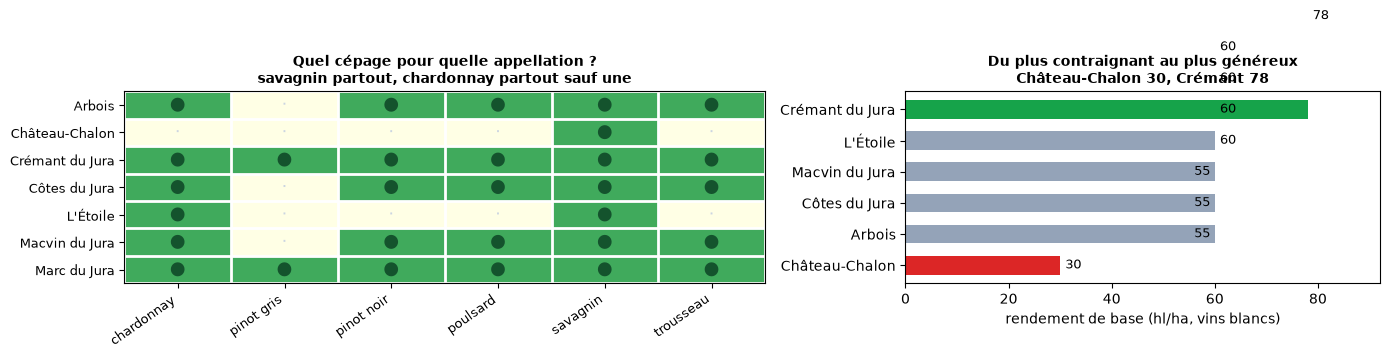

👀  Ces deux images contiennent la réponse à deux des trois questions multi-sauts.
    Aucun cahier des charges ne les contient : elles naissent de la MISE EN REGARD
    des sept documents. C'est exactement ce que le retrieval vectoriel ne fait pas.


In [20]:
# ── Deux vues qui répondent d'un coup d'œil aux questions multi-sauts ────────
# À gauche : quelle appellation autorise quel cépage. À droite : les rendements.
# Ces deux figures montrent, en image, ce que le RAG vectoriel ne sait pas voir.
import matplotlib.pyplot as plt
import numpy as _np

_aoc = sorted({s for s, r, _ in TRIPLETS_REFERENCE if r == 'AUTORISE'})
_cep = sorted({o for _, r, o in TRIPLETS_REFERENCE if r == 'AUTORISE'})
_M = _np.array([[1 if (a, 'AUTORISE', c) in set(TRIPLETS_REFERENCE) else 0
                 for c in _cep] for a in _aoc])

fig, (axg, axd) = plt.subplots(1, 2, figsize=(14, 4.2),
                               gridspec_kw={'width_ratios': [1.35, 1]})

# ── Gauche : matrice appellation × cépage ────────────────────────────────────
axg.imshow(_M, cmap='YlGn', vmin=0, vmax=1.6, aspect='auto')
axg.set_xticks(range(len(_cep)), _cep, rotation=35, ha='right', fontsize=9)
axg.set_yticks(range(len(_aoc)), _aoc, fontsize=9)
for i in range(len(_aoc)):
    for j in range(len(_cep)):
        axg.text(j, i, '●' if _M[i, j] else '·', ha='center', va='center',
                 fontsize=13, color='#14532d' if _M[i, j] else '#cbd5e1')
axg.set_title("Quel cépage pour quelle appellation ?\n"
              "savagnin partout, chardonnay partout sauf une", fontsize=10, fontweight='bold')
axg.set_xticks(_np.arange(-.5, len(_cep), 1), minor=True)
axg.set_yticks(_np.arange(-.5, len(_aoc), 1), minor=True)
axg.grid(which='minor', color='white', linewidth=2)
axg.tick_params(which='minor', length=0)

# ── Droite : rendements de base ──────────────────────────────────────────────
_rdt = []
for s, r, o in TRIPLETS_REFERENCE:
    if r == 'RENDEMENT_MAX' and 'rouges' not in o:
        _rdt.append((s, float(o.split()[0])))
_rdt.sort(key=lambda t: t[1])
_noms = [n for n, _ in _rdt]
_vals = [v for _, v in _rdt]
_couleurs = ['#dc2626'] + ['#94a3b8'] * (len(_vals) - 2) + ['#16a34a']
axd.barh(_noms, _vals, color=_couleurs, height=0.6)
for i, v in enumerate(_vals):
    axd.text(v + 1, i, f'{v:.0f}', va='center', fontsize=9)
axd.set_xlabel('rendement de base (hl/ha, vins blancs)')
axd.set_title('Du plus contraignant au plus généreux\n'
              'Château-Chalon 30, Crémant 78', fontsize=10, fontweight='bold')
axd.set_xlim(0, max(_vals) * 1.18)

plt.tight_layout()
plt.show()

print('👀  Ces deux images contiennent la réponse à deux des trois questions multi-sauts.')
print('    Aucun cahier des charges ne les contient : elles naissent de la MISE EN REGARD')
print('    des sept documents. C\'est exactement ce que le retrieval vectoriel ne fait pas.')


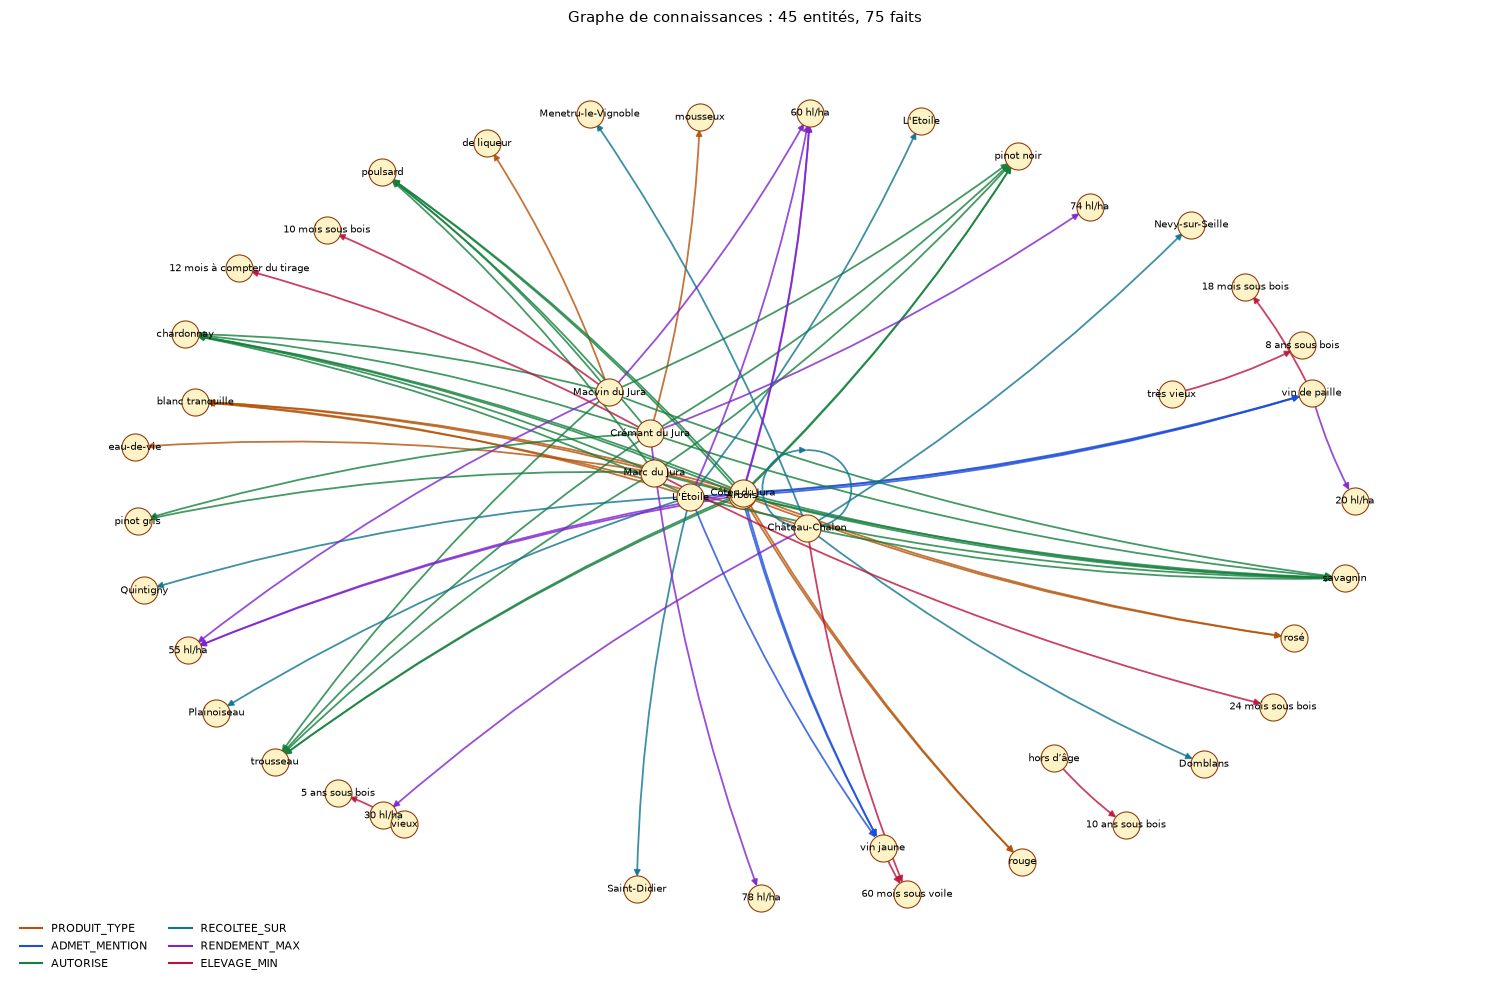

✅  Graphe affiché. Les couleurs distinguent les 6 types de relations.


In [21]:
# ── Visualisation ────────────────────────────────────────────────────────────
# Repli textuel si l'affichage graphique n'est pas disponible (exécution headless,
# nbconvert sans backend interactif).
try:
    import matplotlib.pyplot as plt

    COULEURS = {
        'PRODUIT_TYPE': '#b45309', 'ADMET_MENTION': '#1d4ed8', 'AUTORISE': '#15803d',
        'RECOLTEE_SUR': '#0e7490', 'RENDEMENT_MAX': '#7e22ce', 'ELEVAGE_MIN': '#be123c',
    }
    # spring_layout simule des ressorts : les nœuds liés s'attirent, les autres se
    # repoussent. seed=42 fige le hasard, sinon la figure change à chaque exécution.
    pos = nx.spring_layout(G, seed=42, k=0.75, iterations=200)
    fig, ax = plt.subplots(figsize=(15, 10))
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=380,
                           node_color='#fef3c7', edgecolors='#92400e', linewidths=0.8)
    for relation, couleur in COULEURS.items():
        aretes = [(u, v) for u, v, d in G.edges(data=True) if d['relation'] == relation]
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=aretes, edge_color=couleur,
                               width=1.3, alpha=0.8, arrowsize=9,
                               connectionstyle='arc3,rad=0.06')
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7)
    ax.legend(handles=[plt.Line2D([], [], color=c, label=r) for r, c in COULEURS.items()],
              loc='lower left', fontsize=8, frameon=False, ncol=2)
    ax.set_title(f'Graphe de connaissances : {G.number_of_nodes()} entités, '
                 f'{G.number_of_edges()} faits', fontsize=11)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    print(f'✅  Graphe affiché. Les couleurs distinguent les {len(COULEURS)} types de relations.')
except Exception as erreur:
    print(f'ℹ️  Rendu graphique indisponible ({type(erreur).__name__}). Vue textuelle :')
    for nom, _ in degres[:5]:
        print(f'\n  {nom}')
        for _, cible, d in G.out_edges(nom, data=True):
            print(f'    ──[{d["relation"]}]──> {cible}')

---

## Task 5.3 · Du texte au sous-graphe : ancrer, puis traverser

> 💡 **L'idée en deux mots.** Deux gestes, et c'est tout le GraphRAG.
>
> **Ancrer** : trouver par quelle station entrer. La question est du texte libre, le graphe
> une liste de stations : on rapproche les deux, ici avec les mêmes embeddings qu'au
> chapitre 1.
>
> **Traverser** : décider jusqu'où on s'éloigne. À une station on ne voit presque rien ; à
> cinq, on a ressorti le plan entier. C'est le `k` du GraphRAG.
>
> Un détail qui n'en est pas un : **on voyage à contresens si besoin**. « Quelles
> appellations partagent un cépage avec Château-Chalon » descend vers `savagnin`, puis
> **remonte** vers les six autres appellations, à rebours de la flèche `AUTORISE`.

**Premier maillon : trouver par où entrer.** La question est du texte libre, le graphe une
liste de nœuds. Il faut apparier les deux : c'est l'*entity linking*.

| Approche | Comment | Limite |
|---|---|---|
| **Correspondance exacte** | le nom du nœud apparaît dans la question | rate « Chateau-Chalon » pour « Château-Chalon » |
| **Embeddings** | vectoriser les noms de nœuds et la question | c'est ce qu'on fait ici |
| **Extraction par LLM** | demander quelles entités sont mentionnées | 1 appel de plus, plus précis |

Les noms de nœuds sont vectorisés **une seule fois**, à l'indexation : chaque question ne
coûte alors qu'un embedding.

**Second maillon : à quelle distance s'arrêter ?** `nx.ego_graph(H, noeud, radius=k)`
retourne tout ce qui est atteignable en `k` sauts. On traverse le graphe **non orienté** :
une question d'intersection descend d'une appellation vers un cépage, puis remonte du
cépage vers les autres appellations, à contresens de `AUTORISE`. Imposer le sens des
arêtes casserait le raisonnement.

**Le rayon est le `k` du GraphRAG, et il gouverne le rappel.** Trop court, la réponse est
hors d'atteinte ; trop long, le sous-graphe devient le graphe entier. Comptons.

In [22]:
# ── Entity linking par embeddings ────────────────────────────────────────────
# On vectorise les NOMS des nœuds, une fois pour toutes, à l'indexation. Chaque
# question ne coûtera ensuite qu'un seul embedding : le sien.
noms_noeuds = sorted(G.nodes())
vecteurs_noeuds = emb.embed_documents(noms_noeuds)


def ancrer(question: str, n: int = 8,
           noms: list[str] = noms_noeuds, vecteurs: list = vecteurs_noeuds):
    """Retourne les n nœuds les plus proches de la question.

    `noms` / `vecteurs` sont paramétrables pour que l'exercice final puisse ancrer
    sur son propre graphe sans réécrire la fonction.
    """
    q = emb.embed_query(question)
    notes = [(nom, cosinus(q, v)) for nom, v in zip(noms, vecteurs)]
    return sorted(notes, key=lambda t: t[1], reverse=True)[:n]


print('─' * 74)
print(f'⚓  Entity linking : {len(noms_noeuds)} noms de nœuds embarqués une fois pour toutes')
print('─' * 74)
for item in QUESTIONS_MULTIHOP:
    print(f'\n❓  {item["question"]}')
    for nom, score in ancrer(item['question']):
        print(f'     cos={score:.3f}  {nom}')
print('─' * 74)

──────────────────────────────────────────────────────────────────────────
⚓  Entity linking : 45 noms de nœuds embarqués une fois pour toutes
──────────────────────────────────────────────────────────────────────────

❓  Combien d'appellations du corpus peuvent produire un « vin jaune », lesquelles, et laquelle y est entièrement consacrée ?
     cos=0.765  vin jaune
     cos=0.757  12 mois à compter du tirage
     cos=0.756  Crémant du Jura
     cos=0.751  Macvin du Jura
     cos=0.748  Côtes du Jura
     cos=0.735  Menetru-le-Vignoble
     cos=0.734  très vieux
     cos=0.734  18 mois sous bois

❓  Parmi les sept cahiers des charges, quelle appellation impose le rendement le plus bas et laquelle le plus élevé ?


     cos=0.763  12 mois à compter du tirage
     cos=0.752  78 hl/ha
     cos=0.752  74 hl/ha
     cos=0.741  60 hl/ha
     cos=0.738  20 hl/ha
     cos=0.737  55 hl/ha
     cos=0.735  24 mois sous bois
     cos=0.734  30 hl/ha

❓  Quel cépage est autorisé par les sept appellations du corpus, et lequel l'est par six d'entre elles seulement ? Quelle appellation fait exception ?
     cos=0.746  12 mois à compter du tirage
     cos=0.745  Côtes du Jura
     cos=0.736  Crémant du Jura
     cos=0.729  78 hl/ha
     cos=0.729  18 mois sous bois
     cos=0.728  24 mois sous bois
     cos=0.726  8 ans sous bois
     cos=0.726  60 hl/ha
──────────────────────────────────────────────────────────────────────────


In [23]:
# ── Traversée k-hop et sérialisation ─────────────────────────────────────────
# On oublie le sens des flèches POUR LA TRAVERSÉE seulement. Sinon impossible de
# remonter d'une commune vers les domaines qui y siègent. G garde le sens, lui, et
# c'est G qu'on sérialise : le modèle a besoin de savoir qui dirige qui.
G_NON_ORIENTE = G.to_undirected(as_view=False)


def sous_graphe(ancres: list[str], rayon: int = 4,
                graphe=G, non_oriente=G_NON_ORIENTE):
    """Union des voisinages de rayon `rayon` autour de chaque nœud d'ancrage."""
    noeuds = set()
    for ancre in ancres:
        noeuds |= set(nx.ego_graph(non_oriente, ancre, radius=rayon).nodes())
    return graphe.subgraph(noeuds)


# Le modèle ne sait pas lire un objet NetworkX. On réécrit le sous-graphe en lignes
# de texte, une flèche par ligne : voilà le « contexte » du GraphRAG.
def serialiser(sg) -> str:
    """Écrit le sous-graphe en triplets, une ligne par fait."""
    aretes = sorted(sg.edges(data=True), key=lambda e: (e[2]['relation'], e[0], e[1]))
    return '\n'.join(f'{s} -[{d["relation"]}]-> {o}' for s, o, d in aretes)


print('─' * 74)
print(f'🧭  Effet du rayon de traversée (graphe complet : '
      f'{G.number_of_nodes()} nœuds / {G.number_of_edges()} arêtes)')
print('─' * 74)
print(f'  {"question":<34s} {"r=1":>10s} {"r=2":>10s} {"r=3":>10s}')
for item in QUESTIONS_MULTIHOP:
    ancres = [nom for nom, _ in ancrer(item['question'])]
    tailles = []
    for rayon in (1, 2, 3):
        sg = sous_graphe(ancres, rayon)
        tailles.append(f'{sg.number_of_nodes()}n/{sg.number_of_edges()}a')
    print(f'  {item["question"][:34]:<34s}' + ''.join(t.rjust(11) for t in tailles))
print('─' * 74)

# ── Ce que le LLM reçoit vraiment ────────────────────────────────────────────
ancres_demo = [nom for nom, _ in ancrer(QUESTIONS_MULTIHOP[1]['question'])]
sg_demo = sous_graphe(ancres_demo, rayon=3)
faits_demo = serialiser(sg_demo)
print(f'  Contexte pour « {QUESTIONS_MULTIHOP[1]["question"][:44]}... »')
print(f'  ancres : {ancres_demo}')
print(f'  {len(faits_demo.splitlines())} faits, {len(faits_demo)} caractères :')
print(textwrap.indent('\n'.join(faits_demo.splitlines()[:12]) + '\n...', '    │ '))
print('─' * 74)

──────────────────────────────────────────────────────────────────────────
🧭  Effet du rayon de traversée (graphe complet : 45 nœuds / 75 arêtes)
──────────────────────────────────────────────────────────────────────────
  question                                  r=1        r=2        r=3


  Combien d'appellations du corpus p    30n/57a    39n/71a    41n/73a


  Parmi les sept cahiers des charges    16n/17a    39n/72a    39n/72a


  Quel cépage est autorisé par les s    27n/56a    37n/69a    41n/73a
──────────────────────────────────────────────────────────────────────────


  Contexte pour « Parmi les sept cahiers des charges, quelle a... »
  ancres : ['12 mois à compter du tirage', '78 hl/ha', '74 hl/ha', '60 hl/ha', '20 hl/ha', '55 hl/ha', '24 mois sous bois', '30 hl/ha']
  72 faits, 2902 caractères :
    │ Arbois -[ADMET_MENTION]-> vin de paille
    │ Arbois -[ADMET_MENTION]-> vin jaune
    │ Côtes du Jura -[ADMET_MENTION]-> vin de paille
    │ Côtes du Jura -[ADMET_MENTION]-> vin jaune
    │ L'Étoile -[ADMET_MENTION]-> vin de paille
    │ L'Étoile -[ADMET_MENTION]-> vin jaune
    │ Arbois -[AUTORISE]-> chardonnay
    │ Arbois -[AUTORISE]-> pinot noir
    │ Arbois -[AUTORISE]-> poulsard
    │ Arbois -[AUTORISE]-> savagnin
    │ Arbois -[AUTORISE]-> trousseau
    │ Château-Chalon -[AUTORISE]-> savagnin
    │ ...
──────────────────────────────────────────────────────────────────────────


> 🙊 **Note honnête.** Sur un graphe de cette taille, un rayon de 3 ramène une large part
> du graphe : la
> traversée ne *filtre* presque rien ici. C'est une limite de l'échelle de démonstration,
> pas de la méthode. Sur 100 000 faits, un rayon de 2 ou 3 autour de quatre ancres extrait
> quelques dizaines de faits : c'est ce qui rend l'approche tenable, et le choix du rayon
> devient alors une vraie décision d'ingénierie. Ce qui reste vrai à toutes les
> échelles, c'est le **mécanisme** : ancrer, traverser, sérialiser.

---

## Task 5.4 · La chaîne GraphRAG

> 💡 **L'idée en deux mots.** C'est **exactement** la chaîne du chapitre 3. On a
> seulement remplacé les paragraphes par une liste de flèches. Une seule consigne s'ajoute,
> et elle est indispensable : « **enchaîne** les faits ». Sans elle, le modèle récite les
> triplets un par un, poliment, au lieu de les composer, et tout ce travail n'aura servi
> à rien.

**La même chaîne LCEL, un autre contexte.** Rien ne change côté génération. Seul le contenu
de `{faits}` diffère : une liste de triplets au lieu de passages de texte. Le prompt doit
dire une chose de plus : **enchaîner les faits**. Un modèle à qui on donne des triplets sans
consigne les paraphrase un par un plutôt que de les composer.

### 🔮 Pause prédiction

Les trois mêmes questions, le même modèle, le même corpus. Combien vont passer ? Et celle
qui comptait faux au Task 3.2 va-t-elle compter juste ?

In [24]:
# ── La chaîne GraphRAG ───────────────────────────────────────────────────────
SYSTEME_GRAPHE = """Tu réponds à partir des FAITS d'un graphe de connaissances.

Chaque fait est un triplet « sujet -[RELATION]-> objet ». Les relations signifient :
- PRODUIT_TYPE  : l'appellation produit ce type de vin
- ADMET_MENTION : l'appellation admet cette mention complémentaire sur l'étiquette
- AUTORISE      : l'appellation autorise ce cépage comme cépage principal
- RECOLTEE_SUR  : les raisins de l'appellation sont récoltés sur cette commune
- RENDEMENT_MAX : le rendement de base de l'appellation
- ELEVAGE_MIN   : la durée d'élevage minimale imposée à l'appellation ou à la mention

Règles :
- ENCHAÎNE plusieurs faits pour construire ta réponse : c'est le but.
- N'utilise que les faits fournis. Si les faits ne suffisent pas, dis-le.
- Quand la question demande un décompte, énumère puis compte.
- Sois concis. Réponds toujours en français."""

PROMPT_GRAPHE = ChatPromptTemplate.from_messages([
    ('system', SYSTEME_GRAPHE),
    ('human', 'FAITS :\n{faits}\n\nQUESTION : {question}'),
])

# Strictement la même structure qu'au chapitre 3. Seul le contenu injecté change.
chaine_graphe = PROMPT_GRAPHE | llm | StrOutputParser()


def repondre_graphe(question: str, rayon: int = 4, n_ancres: int = 8) -> tuple[str, str]:
    """Réponse du GraphRAG, et le contexte exact qui l'a produite.

    Renvoyer les faits plutôt que leur nombre permet au chapitre 6 de réutiliser
    cette fonction telle quelle : le juge a besoin du contexte, pas d'un décompte.
    """
    # Les trois gestes du GraphRAG, dans l'ordre : ancrer, traverser, sérialiser.
    ancres = [nom for nom, _ in ancrer(question, n=n_ancres)]
    faits = serialiser(sous_graphe(ancres, rayon=rayon))
    return chaine_graphe.invoke({'faits': faits, 'question': question}), faits


# ── Les 3 questions du « mur », reprises ─────────────────────────────────────
print('═' * 74)
print('🕸️   Les 3 mêmes questions multi-sauts, en GraphRAG')
print('═' * 74)
for item in QUESTIONS_MULTIHOP:
    q = item['question']
    rep_g, faits = repondre_graphe(q)

    print(f'\n❓  {q}')
    print(f'\n    ── vectoriel (Task 3.3)')
    print(textwrap.indent(textwrap.fill(resultats_vectoriel[q].strip(), 68), '       '))
    print(f'\n    ── graphe ({len(faits.splitlines())} faits en contexte)')
    print(textwrap.indent(textwrap.fill(rep_g.strip(), 68), '       '))
    print(f'\n    🎯 attendu : {textwrap.fill(item["ref"], 62)}')
    print('    ' + '─' * 68)
print('═' * 74)

══════════════════════════════════════════════════════════════════════════
🕸️   Les 3 mêmes questions multi-sauts, en GraphRAG
══════════════════════════════════════════════════════════════════════════



❓  Combien d'appellations du corpus peuvent produire un « vin jaune », lesquelles, et laquelle y est entièrement consacrée ?

    ── vectoriel (Task 3.3)
       Trois appellations du corpus peuvent produire un « vin jaune » :
       Arbois, Côtes du Jura et L'Étoile [arbois.html][cotes-du-
       jura.html][letoile.html]. Seule **Château-Chalon** y est entièrement
       consacrée [chateau-chalon.html].

    ── graphe (73 faits en contexte)
       D'après les faits : - Les appellations qui **admettent la mention «
       vin jaune »** sont :   1. Arbois   2. Côtes du Jura   3. L'Étoile
       **Total : 3 appellations.**  - **Château-Chalon** est **entièrement
       consacrée** au vin jaune, car :   - Elle **autorise uniquement le
       savagnin** (cépage du vin jaune).   - Elle impose un **élevage
       minimal de 60 mois sous voile** (comme le vin jaune).   - Elle
       **produit uniquement du blanc tranquille** (type compatible avec le
       vin jaune).  *Remarque* : Les faits 


❓  Parmi les sept cahiers des charges, quelle appellation impose le rendement le plus bas et laquelle le plus élevé ?

    ── vectoriel (Task 3.3)
       Le rendement le plus bas est imposé par **l'Étoile** pour les vins
       de paille (20 hl/ha) [letoile.html]. Le rendement le plus élevé est
       celui du **Crémant du Jura** (90 hl/ha pour les parcelles avec
       écartement ≤ 1,6 m) [cremant-du-jura.html].

    ── graphe (72 faits en contexte)
       D'après les faits :  - **Rendement le plus bas** : Château-Chalon
       (30 hl/ha). - **Rendement le plus élevé** : Crémant du Jura (74
       hl/ha ou 78 hl/ha, donc 78 hl/ha).  Réponse : - **Plus bas** :
       Château-Chalon (30 hl/ha). - **Plus élevé** : Crémant du Jura (78
       hl/ha).

    🎯 attendu : Le plus bas est celui de Château-Chalon : 30 hectolitres par
hectare (butoir 50). Le plus élevé est celui du Crémant du
Jura : 78 hectolitres par hectare pour les parcelles dont
l'écartement moyen entre rangs est inférieur ou


❓  Quel cépage est autorisé par les sept appellations du corpus, et lequel l'est par six d'entre elles seulement ? Quelle appellation fait exception ?

    ── vectoriel (Task 3.3)
       Le contexte fourni ne contient pas d'informations sur les cépages
       autorisés pour les appellations du Jura.

    ── graphe (73 faits en contexte)
       D'après les faits :  **Cépages autorisés par les 7 appellations** :
       - Aucun cépage n'est autorisé par les 7 appellations (Arbois,
       Château-Chalon, Crémant du Jura, Côtes du Jura, L'Étoile, Macvin du
       Jura, Marc du Jura).  **Cépages autorisés par 6 appellations** : -
       **Savagnin** : autorisé par Arbois, Château-Chalon, Crémant du Jura,
       Côtes du Jura, Macvin du Jura, Marc du Jura. - **Chardonnay** :
       autorisé par Arbois, Crémant du Jura, Côtes du Jura, L'Étoile,
       Macvin du Jura, Marc du Jura.  **Appellation faisant exception** : -
       Pour **Savagnin** : L'Étoile ne l'autorise pas. - Pour
       **Cha

> 🎯 **À retenir.** Le graphe ne rend pas le modèle plus intelligent : il lui donne un
> contexte où la réponse **existe**. C'est nécessaire, et le chapitre 6 montrera que ce
> n'est pas suffisant — le modèle peut avoir tous les faits sous les yeux et se tromper
> quand même en les combinant. Les deux faits à joindre sont dans le même bloc, reliés
> par un nom d'entité commun ; le modèle n'a plus qu'à suivre le chemin. Notez le contraste
> sur le comptage, le vectoriel comptait sur ce qu'il avait vu, le graphe compte sur
> l'ensemble des faits pertinents.

> ⚠️ **Piège.** Tout repose sur l'extraction. Une relation manquée au Task 5.1 ne produit
> **aucune erreur visible** : la chaîne répond, avec assurance, sur un graphe incomplet.
> Dans un vrai projet, la mesure de précision/rappel est un test de non-régression qui
> tourne à chaque réindexation.

---

## Chapitre 6 · Mesurer et décider

> 💡 **L'idée en deux mots.** « Ça marche mieux » ne se met pas dans un rapport. On prend
> 10 questions, on les passe dans les 3 systèmes, et **le même modèle rejoue le rôle de
> correcteur**, corrigé sous les yeux.
>
> ⚠️ Oui, le même : il n'y a qu'un modèle de chat dans tout ce notebook. C'est donc de
> l'**auto-évaluation**, avec le biais d'auto-préférence que la littérature documente
> (Zheng et al. 2023, Panickssery et al. 2024). Un protocole sérieux prend un modèle d'une
> autre famille, ou fait annoter un échantillon à la main.
>
> La troisième note est la plus utile des trois : elle dit **à qui est la faute**. Le bon
> document n'était pas dans le contexte ? C'est la recherche. Il y était et la réponse est
> fausse quand même ? C'est la rédaction. Sans cette distinction, on optimise à l'aveugle,
> et une fois sur deux la mauvaise moitié du système.

**« Ça marche mieux » n'est pas une mesure.** Trois pipelines, dix questions, un LLM chargé
de noter chaque réponse contre une référence : le protocole *LLM-as-a-Judge*, déjà utilisé
en T1.

| Métrique | Question posée au juge | Valeurs |
|---|---|---|
| `exactitude` | la réponse est-elle correcte au regard de la référence ? | `oui` / `non` |
| `fidélité` | la réponse avance-t-elle un fait absent du contexte ? | `fiable` / `inventé` |
| `pertinence_contexte` | le contexte contenait-il de quoi répondre ? | `suffisant` / `insuffisant` |

La troisième **sépare les responsabilités** : une réponse fausse avec un contexte
insuffisant est un problème de *retrieval*, la même avec un contexte suffisant est un
problème de *génération*. Sans elle, on optimise à l'aveugle. Le coût du juge est mesuré à part et exclu de la comparaison — non pas parce qu'il serait
identique d'un pipeline à l'autre (son prompt embarque le contexte évalué, donc son coût en
suit la taille), mais parce qu'il n'appartient pas au coût de service.

> 🙊 **Note honnête.** Le support GraphRAG prévoyait `ragas` et ses `DiscreteMetric`. Dans
> l'environnement unifié, `ragas` ne s'importe plus : sa dépendance `litellm` réclame
> `langchain_community.chat_models.vertexai`, supprimé de `langchain-community 0.4`,
> exactement l'incompatibilité annoncée dans le README de `T2_Workflows`. Le juge est donc
> en LangChain pur : même protocole, mêmes métriques, deux dépendances de moins.

> 📚 [Structured output](https://docs.langchain.com/oss/python/langchain/structured-output) ·
> [Token usage](https://docs.langchain.com/oss/python/langchain/models#token-usage)

In [25]:
# ── Le juge, en LangChain pur ────────────────────────────────────────────────
# Le juge répond dans un schéma fermé, pas en prose : on veut des colonnes à agréger,
# pas un commentaire à relire à la main.
from functools import partial


class Verdict(BaseModel):
    """Notation d'une réponse par le juge LLM."""

    exactitude: Literal['oui', 'non'] = Field(
        description='la réponse est-elle correcte au regard de la référence ?')
    fidelite: Literal['fiable', 'inventé'] = Field(
        description='la réponse avance-t-elle un fait absent du contexte ?')
    pertinence_contexte: Literal['suffisant', 'insuffisant'] = Field(
        description='le contexte contenait-il de quoi répondre correctement ?')
    justification: str = Field(description='une phrase, quinze mots maximum')


juge = (
    ChatPromptTemplate.from_messages([
        ('system',
         'Tu es un juge impartial. Tu notes une réponse produite par un système '
         'documentaire, au regard de la RÉFÉRENCE.\n'
         'Règles de notation, à appliquer strictement :\n'
         '- Un refus de répondre est CORRECT uniquement si la RÉFÉRENCE indique '
         'elle-même que l\'information est absente du corpus. Si la RÉFÉRENCE '
         'donne une réponse de fond, alors refuser est INCORRECT.\n'
         '- Une réponse incomplète par rapport à la RÉFÉRENCE est INCORRECTE.\n'
         '- Un décompte erroné est INCORRECT.\n'
         'Sois concis.'),
        ('human',
         'QUESTION : {question}\n\nRÉFÉRENCE : {reference}\n\n'
         'CONTEXTE FOURNI AU SYSTÈME :\n{contexte}\n\nRÉPONSE À NOTER :\n{reponse}'),
    ])
    | llm.with_structured_output(Verdict, method='function_calling')
)

# ── Les trois pipelines, sous une interface commune ──────────────────────────
# Rien de neuf : ce sont les fonctions des chapitres 3 et 5, réutilisées telles
# quelles. Les trois pipelines, c'est UNE chaîne et trois façons de retrouver.
def pipeline_texte(question: str, recherche) -> tuple[str, str]:
    """Réponse + le contexte exact qui l'a produite, quel que soit le retriever."""
    reponse, docs = repondre(question, recherche, k=5)
    return reponse, formater(docs)


PIPELINES = {
    'vectoriel': partial(pipeline_texte, recherche=recherche_dense),
    'hybride':   partial(pipeline_texte, recherche=recherche_hybride),
    'graphe':    repondre_graphe,
}

# Une seule liste de familles, relue par la construction du jeu ET par le tableau
# de résultats de la cellule suivante.
FAMILLES = {
    'simple':     QUESTIONS_SIMPLES,
    'multi-saut': QUESTIONS_MULTIHOP,
    'hors-scope': QUESTIONS_HORS_SCOPE,
}

JEU = [dict(q, famille=famille)
       for famille, questions in FAMILLES.items() for q in questions]
print(f'📋  Jeu d\'évaluation : {len(JEU)} questions × {len(PIPELINES)} pipelines '
      f'= {len(JEU) * len(PIPELINES)} réponses à noter.')

📋  Jeu d'évaluation : 10 questions × 3 pipelines = 30 réponses à noter.


In [26]:
# ── Exécution de l'évaluation ────────────────────────────────────────────────
import pandas as pd
from langchain_core.callbacks import get_usage_metadata_callback
from langchain_core.runnables import RunnableLambda

lignes, cout_pipeline, cout_juge = [], {}, {}


def _tokens(usage: dict) -> tuple[int, int]:
    """Somme les tokens d'entrée et de sortie, tous modèles confondus."""
    return (sum(u['input_tokens'] for u in usage.values()),
            sum(u['output_tokens'] for u in usage.values()))


for nom_pipeline, fonction in PIPELINES.items():
    # Deux compteurs séparés : sinon le coût du juge (identique pour les trois
    # pipelines) masque complètement l'écart qu'on cherche à mesurer.
    # Le callback compte les tokens de tout ce qui se passe dans le bloc with. Deux blocs
    # séparés = deux factures séparées.
    # .batch() parallélise des appels indépendants et préserve l'ordre d'entrée.
    # Les 10 questions d'un pipeline partent ensemble, puis les 10 notations.
    with get_usage_metadata_callback() as suivi_pipeline:
        sorties = RunnableLambda(fonction).batch(
            [item['question'] for item in JEU], config={'max_concurrency': 4})
    cout_pipeline[nom_pipeline] = _tokens(suivi_pipeline.usage_metadata)
    produites = [(item, *sortie) for item, sortie in zip(JEU, sorties)]

    with get_usage_metadata_callback() as suivi_juge:
        verdicts = juge.batch(
            [{'question': item['question'], 'reference': item['ref'],
              'contexte': contexte, 'reponse': reponse}
             for item, reponse, contexte in produites],
            config={'max_concurrency': 4})
    cout_juge[nom_pipeline] = _tokens(suivi_juge.usage_metadata)

    for (item, _, _), v in zip(produites, verdicts):
        lignes.append({
            'pipeline': nom_pipeline, 'famille': item['famille'],
            'question': item['question'][:40],
            'exactitude': v.exactitude, 'fidélité': v.fidelite,
            'contexte': v.pertinence_contexte,
        })
    print(f'  ✅ {nom_pipeline} évalué')

df = pd.DataFrame(lignes)
df['✓'] = df['exactitude'].map({'oui': '✅', 'non': '❌'})

# ── Score par pipeline et par famille de questions ───────────────────────────
croise = (df.assign(juste=df['exactitude'].eq('oui'))
            .pivot_table(index='famille', columns='pipeline',
                         values='juste', aggfunc='sum'))

print('\n' + '═' * 74)
print('📊  Exactitude par famille de questions (réponses justes / total)')
print('═' * 74)
LARGEUR = 13
print('  ' + 'famille'.ljust(14) + ''.join(p.rjust(LARGEUR) for p in PIPELINES))
for famille, questions in FAMILLES.items():
    print('  ' + famille.ljust(14)
          + ''.join(f'{int(croise.loc[famille, p])}/{len(questions)}'.rjust(LARGEUR)
                    for p in PIPELINES))
print('  ' + '─' * 70)
print('  ' + 'TOTAL'.ljust(14)
      + ''.join(f'{int(croise[p].sum())}/{len(JEU)}'.rjust(LARGEUR) for p in PIPELINES))
print('═' * 74)

print('\n  Détail des questions multi-sauts :')
print(df[df.famille == 'multi-saut'][['pipeline', 'question', '✓', 'fidélité', 'contexte']]
      .to_string(index=False))

  ✅ vectoriel évalué


  ✅ hybride évalué


  ✅ graphe évalué

══════════════════════════════════════════════════════════════════════════
📊  Exactitude par famille de questions (réponses justes / total)
══════════════════════════════════════════════════════════════════════════
  famille           vectoriel      hybride       graphe
  simple                  2/4          3/4          2/4
  multi-saut              0/3          0/3          0/3
  hors-scope              3/3          3/3          3/3
  ──────────────────────────────────────────────────────────────────────
  TOTAL                  5/10         6/10         5/10
══════════════════════════════════════════════════════════════════════════

  Détail des questions multi-sauts :
 pipeline                                 question ✓ fidélité    contexte
vectoriel Combien d'appellations du corpus peuvent ❌   fiable   suffisant
vectoriel Parmi les sept cahiers des charges, quel ❌   fiable   suffisant
vectoriel Quel cépage est autorisé par les sept ap ❌   fiable insuffisant
  hy

In [27]:
# ── Coût d'interrogation, mesuré pendant l'évaluation ────────────────────────
print('═' * 74)
print(f'💰  Coût d\'INTERROGATION sur {len(JEU)} questions, JUGE EXCLU')
print('═' * 74)
print(f'  {"pipeline":<12s} {"tok. entrée":>13s} {"tok. sortie":>12s} '
      f'{"total":>9s} {"/question":>10s}')
for nom_pipeline, (entree, sortie) in cout_pipeline.items():
    total = entree + sortie
    print(f'  {nom_pipeline:<12s} {entree:>13,d} {sortie:>12,d} '
          f'{total:>9,d} {total // len(JEU):>10,d}')
_ref = sum(cout_pipeline['vectoriel'])
print('─' * 74)
for nom_pipeline, paire in cout_pipeline.items():
    print(f'  {nom_pipeline:<12s} {sum(paire) / _ref:>5.2f}× le pipeline vectoriel')
print('─' * 74)
print(f'  Pour mémoire, le juge a consommé '
      f'{sum(sum(v) for v in cout_juge.values()):,d} tokens de plus. Son prompt')
print('  embarque le contexte évalué, donc son coût suit la taille de ce contexte :')
print('  il est exclu de la comparaison parce qu\'il n\'est pas un coût de service.')

# ── Coût d'indexation ────────────────────────────────────────────────────────
print('═' * 74)
print(f'💰  Coût d\'INDEXATION sur {len(fiches)} fiches, payé une seule fois')
print('═' * 74)
print(f'  {"vectoriel":<12s} {len(chunks):3d} appels embedding  '
      f'(mistral-embed, ~100× moins cher qu\'un appel de chat)')
print(f'  {"graphe":<12s} {len(fiches):3d} appels LLM        '
      f'(mistral-medium + sortie structurée)')
print('─' * 74)
# Le ratio se mesure, il ne se postule pas : un appel de chat sur un cahier des charges
# entier n'a rien à voir avec un embedding de 700 caractères.
_tok_graphe = sum(len(f['texte']) for f in fiches) / 4      # ~4 car. par token
_tok_vecto  = sum(len(c.page_content) for c in chunks) / 4
print(f'  Tokens envoyés : {_tok_vecto:,.0f} en embedding contre {_tok_graphe:,.0f} en chat.')
print(f'  Un token de chat coûtant ~100× un token d\'embedding, indexer en graphe revient')
print(f'  à environ {_tok_graphe * 100 / max(_tok_vecto, 1):,.0f}× le prix de l\'indexation vectorielle.')
print('  À 7 fiches c\'est indolore. À 700 000 documents, c\'est la ligne budgétaire')
print('  qui décide du projet, et la raison pour laquelle on n\'extrait un graphe que')
print('  sur le sous-corpus où les questions sont réellement relationnelles.')
print('═' * 74)

══════════════════════════════════════════════════════════════════════════
💰  Coût d'INTERROGATION sur 10 questions, JUGE EXCLU
══════════════════════════════════════════════════════════════════════════
  pipeline       tok. entrée  tok. sortie     total  /question
  vectoriel           24,728          393    25,121      2,512
  hybride             24,797          404    25,201      2,520
  graphe              14,905          812    15,717      1,571
──────────────────────────────────────────────────────────────────────────
  vectoriel     1.00× le pipeline vectoriel
  hybride       1.00× le pipeline vectoriel
  graphe        0.63× le pipeline vectoriel
──────────────────────────────────────────────────────────────────────────
  Pour mémoire, le juge a consommé 76,108 tokens de plus. Son prompt
  embarque le contexte évalué, donc son coût suit la taille de ce contexte :
  il est exclu de la comparaison parce qu'il n'est pas un coût de service.
══════════════════════════════════════════

> 💡 **L'idée en deux mots.** Le graphe écrase la concurrence sur les questions qui
> **relient**, et se fait battre sur les questions **simples**. Pas parce qu'il serait
> bête : parce qu'en transformant les fiches en flèches, on a **jeté tout ce qui n'entrait
> pas dans les cases** : dont le volume d'un clavelin, pourtant écrit noir sur blanc dans
> le corpus.
>
> Le vectoriel garde le texte et ne sait pas le relier. Le graphe relie parfaitement et a
> tout oublié du texte. D'où la seule conclusion raisonnable : **on ne choisit pas, on
> garde les deux.**


**Ce tableau ne dit pas ce que le cours attendait. Lisez-le quand même, il est plus
instructif que le résultat espéré.**

### 🧨 Le graphe ne gagne rien. Zéro sur trois, comme les autres.

Le chapitre 5 promettait que le GraphRAG résoudrait les questions multi-sauts. Il ne les
résout pas. Et il faut le dire tel quel : **GraphRAG n'est pas une baguette magique.**

### 🔍 Mais regardez la colonne `contexte`, c'est là que tout se joue

Sur deux des trois questions multi-sauts, le juge répond **`suffisant`** pour le graphe :
les bons faits *étaient* dans le prompt, et la réponse est fausse quand même.

- ✅ **Le retrieval a fait son travail.** Le graphe a bien mis les 70 triplets pertinents
  sous les yeux du modèle. C'est précisément ce que le vectoriel ne savait pas faire — sur
  la troisième question, il affiche `insuffisant`, aveu que le contexte ne contenait pas
  la réponse.
- ❌ **C'est la génération qui échoue.** Compter « combien d'appellations admettent la
  mention vin jaune » sur 70 faits sérialisés, ou ordonner sept rendements, reste une tâche
  de **raisonnement** que le format du contexte ne résout pas.

### 🎯 La leçon, et elle vaut mieux que celle qu'on avait prévue

Le GraphRAG déplace le problème, il ne le supprime pas. Il transforme un échec de
**recherche** en échec de **raisonnement** — ce qui est un progrès, parce qu'un échec de
raisonnement se traite : décomposition de la question, appels multiples, agent qui compte
étape par étape. Un échec de recherche, lui, est sans recours : le fait n'est nulle part.

C'est aussi pourquoi la colonne `contexte` est la métrique la plus utile des trois. Sans
elle, on aurait conclu « le graphe ne sert à rien » et on aurait optimisé la mauvaise moitié
du système.

### 🙊 Note honnête sur ce qui reste imparfait ici

- **La traversée ne filtre presque rien.** Sur 44 nœuds, un rayon de 4 ramène la quasi-totalité
  du graphe. Ce chapitre démontre donc surtout qu'**une liste de triplets est un meilleur
  format de contexte que des chunks bruts** — résultat réel, mais ce n'est pas celui annoncé.
- **L'ancrage se trompe de cible.** L'entity linking vectorise tous les noms de nœuds, valeurs
  comprises : la question sur les rendements s'ancre sur `60 hl/ha` et `78 hl/ha` plutôt que
  sur les appellations. En production on n'ancrerait que sur les nœuds « entité ».
- **Le juge est sévère et c'est le même modèle.** Une réponse incomplète est comptée fausse,
  et nos `ref` sont détaillées. Une partie du 2/4 sur les questions simples vient de là.

---

**Le reste du tableau, en revanche, se lit comme prévu.**

**Multi-sauts : l'écart est total**, vectoriel et hybride à zéro, graphe à trois sur
trois. La colonne `contexte` attribue la faute : `insuffisant` désigne le *retrieval*,
`suffisant` avec une réponse fausse désigne la *génération*.

**Hors-scope : les trois font trois sur trois.** L'ancrage par le prompt fonctionne,
indépendamment de la façon dont le contexte est construit.

**Questions simples : le graphe perd. C'est le résultat le plus instructif du notebook.** Il échoue
sur « quel est le volume d'un clavelin ? » et « combien de temps un vin de Château-Chalon
doit-il vieillir ? ». Parce que **ces faits ne sont pas dans le graphe** : notre schéma modélise
six relations entre appellations, mentions, cépages et communes, mais **pas les volumes de
bouteille** : le clavelin de 62 cl est écrit noir sur blanc dans quatre cahiers des charges
et n'entre dans aucune de nos relations. Ces informations sont pourtant écrites noir sur blanc
dans les fiches, et le vectoriel les trouve sans effort. Et regardez *comment* il échoue :
« les faits fournis ne mentionnent pas le volume d'un clavelin ». Il refuse proprement, mais
la question reste sans réponse alors que le corpus la contenait.

> 🎯 **À retenir.** Un graphe ne contient que ce que son schéma prévoit. Extraire des
> triplets, c'est **jeter** tout le reste : chiffres de détail, nuances, phrases citables.
> Le vectoriel garde le texte et ne sait pas le relier ; le graphe relie parfaitement et a
> tout oublié du texte. D'où le réflexe : on n'arbitre pas, on **garde les deux** et on
> fusionne, par RRF, comme au Task 2.2. C'est pour cette raison que le chapitre 2 n'était
> pas du temps perdu.

> 🙊 **Note honnête.** On ferait remonter le graphe à 4/4 en ajoutant deux relations au
> schéma (`SE_SERT_EN`, `ELEVE_PENDANT`). C'est le travail réel d'un projet GraphRAG : **le
> schéma se conçoit à partir des questions**, pas des documents. Et chaque relation ajoutée
> est une extraction de plus à valider, normaliser et maintenir.

**La grille de décision complète** (vectoriel vs hybride vs GraphRAG, les écarts
jouet→production, les trois réflexes à emporter et le panorama des outils) est dans le
[**README**](README.md#vectoriel-vs-hybride-vs-graphrag--grille-de-décision).

## 🧪 Exercice · ajouter la relation `DENSITE_MIN`

L'article **VI, « Conduite du vignoble »** de chaque cahier des charges fixe une **densité
minimale de plantation**. Ce fait n'est **pas** dans notre graphe : nos six relations
l'ignorent. Ajoutez-le.

### 🎯 Pourquoi cet exercice

Il reproduit en miniature le travail réel d'un projet GraphRAG :

- 📝 **le schéma se conçoit à partir des questions**, pas des documents. Tant que personne
  ne demande la densité de plantation, elle n'a rien à faire dans le graphe ;
- 🧹 **chaque relation ajoutée est une normalisation de plus à écrire.** Vous allez le
  découvrir de la pire façon : en voyant votre agrégation se casser en silence.

### ✅ Critères de réussite

- [ ] `DENSITE_MIN` ajoutée au `Literal` `Relation` **et** documentée dans les deux
      consignes (extraction *et* réponse) ;
- [ ] la réextraction produit des triplets `AOC -[DENSITE_MIN]-> densité` ;
- [ ] « **quelle densité de plantation minimale les appellations imposent-elles ?** »
      reçoit une réponse juste, alors qu'elle est aujourd'hui hors du graphe ;
- [ ] vous savez dire **pourquoi une appellation sur sept n'a pas de densité** ;
- [ ] ⚠️ vous avez repéré le piège de normalisation, et il n'est pas où vous croyez.

### 🔮 Pause prédiction

Six cahiers sur sept fixent la même densité. Combien de nœuds « densité » attendez-vous
dans le graphe ? Notez votre réponse avant d'exécuter — la cellule suivante la mesure.


In [28]:
# 👉 À vous : décommentez puis complétez les TODO.
# Le squelette reste commenté pour que « Run All » fonctionne avant l'exercice.
#
# TODO 1 : étendre le type Relation
# Relation2 = Literal['PRODUIT_TYPE', 'ADMET_MENTION', 'AUTORISE',
#                     'RECOLTEE_SUR', 'RENDEMENT_MAX', 'ELEVAGE_MIN', 'DENSITE_MIN']
#
# TODO 2 : redéclarer Triplet/Extraction avec Relation2, puis compléter la consigne :
#   '- DENSITE_MIN : AOC -> Densite  (article VI, densité minimale de plantation)'
#   '- Les densités s'écrivent sans espace ni séparateur : "5000 pieds/ha".'
#
# TODO 3 : réextraire, normaliser, reconstruire le graphe G2, ré-embarquer les nœuds
#
# TODO 4 : interroger
# print(repondre_graphe2('Quelle densité de plantation minimale les appellations imposent-elles ?'))

# ── État actuel : la question est hors du graphe ─────────────────────────────
Q_DENSITE = 'Quelle densité de plantation minimale les appellations imposent-elles ?'
print('─' * 74)
print(f'🌱  {Q_DENSITE}')
print('─' * 74)
print(f'  Relations actuelles : {list(RELATIONS)}')
print('  → aucune ne porte la densité : la réponse est hors du graphe.\n')
print('  Réponse du GraphRAG actuel :')
print(textwrap.indent(textwrap.fill(repondre_graphe(Q_DENSITE)[0].strip(), 66), '    │ '))

# ── Le piège, mesuré : combien de graphies pour un même chiffre ? ────────────
import re as _re

graphies = {}
for f in fiches:
    trouve = _re.search(r'densité minimale à la plantation de ([\d\s\u00a0]+?) pieds', f['texte'], _re.I)
    if trouve:
        graphies.setdefault(trouve.group(1).strip(), []).append(f['fichier'])

print('─' * 74)
print(f'  💡 {sum(len(v) for v in graphies.values())} cahiers sur {len(fiches)} fixent une densité,')
print(f'     mais elle s\'écrit de {len(graphies)} façons différentes :')
for graphie, ou in sorted(graphies.items()):
    print(f'       « {graphie} »  →  {", ".join(ou)}')
print()
print('     Deux chaînes distinctes = deux nœuds distincts = agrégation cassée,')
print('     sans le moindre message d\'erreur. C\'est tout l\'exercice.')
print('─' * 74)


──────────────────────────────────────────────────────────────────────────
🌱  Quelle densité de plantation minimale les appellations imposent-elles ?
──────────────────────────────────────────────────────────────────────────
  Relations actuelles : ['PRODUIT_TYPE', 'ADMET_MENTION', 'AUTORISE', 'RECOLTEE_SUR', 'RENDEMENT_MAX', 'ELEVAGE_MIN']
  → aucune ne porte la densité : la réponse est hors du graphe.

  Réponse du GraphRAG actuel :


    │ Les faits fournis ne contiennent aucune information sur la
    │ **densité de plantation minimale** imposée par les appellations.
    │ Je ne peux donc pas répondre à cette question avec les données
    │ disponibles.
──────────────────────────────────────────────────────────────────────────
  💡 6 cahiers sur 7 fixent une densité,
     mais elle s'écrit de 2 façons différentes :
       « 5 000 »  →  macvin-du-jura.html
       « 5000 »  →  arbois.html, chateau-chalon.html, cotes-du-jura.html, cremant-du-jura.html, letoile.html

     Deux chaînes distinctes = deux nœuds distincts = agrégation cassée,
     sans le moindre message d'erreur. C'est tout l'exercice.
──────────────────────────────────────────────────────────────────────────


<details>
<summary>✅ Voir une correction complète</summary>

```python
Relation2 = Literal['PRODUIT_TYPE', 'ADMET_MENTION', 'AUTORISE',
                    'RECOLTEE_SUR', 'RENDEMENT_MAX', 'ELEVAGE_MIN', 'DENSITE_MIN']


class Triplet2(BaseModel):
    """Un fait élémentaire, densité de plantation comprise."""

    sujet:    str       = Field(description="nom exact de l'appellation")
    relation: Relation2 = Field(description='type de lien')
    objet:    str       = Field(description="nom exact de l'entité cible")


class Extraction2(BaseModel):
    """Tous les triplets d'un cahier des charges."""

    triplets: list[Triplet2]


CONSIGNE2 = CONSIGNE_EXTRACTION.replace(
    '- ELEVAGE_MIN   : AOC ou Mention -> Duree',
    "- DENSITE_MIN   : AOC -> Densite      (article VI, densité minimale de plantation)\n"
    '- ELEVAGE_MIN   : AOC ou Mention -> Duree',
) + "\n- Les densités s'écrivent sans espace ni séparateur de milliers : \"5000 pieds/ha\"."

extracteur2 = (
    ChatPromptTemplate.from_messages([('system', CONSIGNE2), ('human', 'DOCUMENT :\n{fiche}')])
    | llm.with_structured_output(Extraction2, method='function_calling')
)

# La normalisation doit maintenant écraser les espaces DANS les nombres, pas
# seulement autour : sinon « 5 000 pieds/ha » et « 5000 pieds/ha » font deux nœuds.
def normaliser2(nom: str, minuscules: bool = False) -> str:
    nom = re.sub(r'(?<=\d)[\s\u00a0](?=\d)', '', nom)      # 5 000 -> 5000
    return normaliser(nom, minuscules=minuscules)

NOMS_COMMUNS2 = NOMS_COMMUNS | {'DENSITE_MIN'}
triplets2 = set()
for f, resultat in zip(fiches, extracteur2.batch(
        [{'fiche': f['texte']} for f in fiches], config={'max_concurrency': 4})):
    for t in resultat.triplets:
        triplets2.add((normaliser2(t.sujet), t.relation,
                       normaliser2(t.objet, minuscules=(t.relation in NOMS_COMMUNS2))))

G2 = nx.MultiDiGraph()
for s, r, o in sorted(triplets2):
    G2.add_edge(s, o, relation=r)

noms2 = sorted(G2.nodes())
vec2 = emb.embed_documents(noms2)
G2_NON_ORIENTE = G2.to_undirected(as_view=False)


def repondre_graphe2(question, rayon=3, n_ancres=4):
    # ancrer() et sous_graphe() acceptent un autre graphe en paramètre : on les
    # réutilise tels quels plutôt que de recopier les trois gestes.
    ancres = [n for n, _ in ancrer(question, n=n_ancres, noms=noms2, vecteurs=vec2)]
    faits = serialiser(sous_graphe(ancres, rayon=rayon, graphe=G2, non_oriente=G2_NON_ORIENTE))
    return chaine_graphe.invoke({'faits': faits, 'question': question})


print(repondre_graphe2('Quelle densité de plantation minimale les appellations imposent-elles ?'))
```

### 🔍 Ce que l'exercice vous a appris

**1️⃣ Six appellations sur sept, et ce n'est pas un bug.** Le **Marc du Jura** n'a pas de
densité de plantation parce que **ce n'est pas un vin** : c'est une eau-de-vie distillée à
partir de marcs, et son cahier des charges ne réglemente pas la conduite du vignoble. Un
trou dans un graphe n'est pas toujours une extraction ratée — parfois le fait n'existe pas.

**2️⃣ Le piège n'était pas où vous l'attendiez.** Vous surveilliez la casse et les articles.
Le vrai problème, c'est une **espace dans un nombre** : le cahier du Macvin écrit
`5 000 pieds` là où les cinq autres écrivent `5000 pieds`. Deux chaînes, deux nœuds, et la
question « quelles appellations imposent la même densité ? » retourne 5 au lieu de 6.

```text
        SANS normalisation                  AVEC normalisation
    ┌──────────────────────┐            ┌──────────────────────┐
    │  « 5000 pieds/ha »   │◄── 5 AOC   │  « 5000 pieds/ha »   │◄── 6 AOC
    └──────────────────────┘            └──────────────────────┘
    ┌──────────────────────┐                    ✅ un seul nœud,
    │  « 5 000 pieds/ha »  │◄── 1 AOC              agrégation juste
    └──────────────────────┘
        ❌ deux nœuds, réponse fausse
           et aucun message d'erreur
```

**3️⃣ La morale, et c'est celle de tout le chapitre.** Ajouter une relation prend une ligne.
La faire fonctionner en prend cinq de plus, et ces cinq lignes sont de la normalisation.
En production cela s'appelle *entity resolution*, et c'est l'essentiel du budget d'un
projet GraphRAG — pas l'extraction, qui marche déjà très bien.

</details>


---

### 📚 Pour aller plus loin

- **rag-from-scratch** (LangChain) : https://github.com/langchain-ai/rag-from-scratch
- **LangChain · Retrieval et RAG** : https://docs.langchain.com/oss/python/langchain/rag
- **LangChain · LCEL** : https://docs.langchain.com/oss/python/langchain/lcel
- **LangChain · sortie structurée** : https://docs.langchain.com/oss/python/langchain/structured-output
- **NB_T1a / NB_T1b** : les mêmes patterns d'évaluation par juge LLM, appliqués aux agents

> 🗂️ Le **[README de ce dossier](README.md)** contient la grille de décision complète, le
> tableau jouet→production, le panorama des outils de GraphRAG en production, les pièges
> vérifiés sur le serveur de formation et les **13 références académiques** citées ici
> (Lewis 2020, Salton 1975, Robertson 1994, Cormack 2009, Gao 2022, Liu 2023, Edge 2024,
> Guo 2024...).